# Funding the Fall: A Cross-Venue Carry and Cascade Risk Crypto Perpetual Futures Strategy

**Authors:** John Beecher (12302422), Antonio Braz (12496713), Jean-Luc Choiseul (12506535), Jean Mauratille (12328252)

**FINM 33150 — Quantitative Trading Strategies** | University of Chicago | 2026

## Abstract

We construct a two-component strategy for crypto perpetual futures that combines
**funding-rate carry** (85% baseline allocation) with **cascade-driven opportunistic
shorts** (up to 15% allocation). The carry leg harvests cross-venue funding spreads on
BTC, ETH, SOL, HYPE, and DOGE across seven exchanges (Hyperliquid, Lighter, OKX, Kraken,
Binance, Bybit, dYdX), maintaining delta neutrality through offsetting long/short
positions. The cascade leg uses a feedback-loop liquidation simulator calibrated to real
open interest data to identify periods of market fragility — when OI/depth ratios are
high, return distributions become negatively skewed due to forced liquidation cascades,
making short positions positive expected value. In elevated-risk regimes the strategy
scales into shorts on the most fragile coins while simultaneously reducing carry
exposure as a defensive overlay.

We backtest with an event-loop engine operating on 8-hour funding epochs with
position-level isolated margin tracking. Over the 12-month sample (Mar 2025–Mar 2026),
the strategy produced a total return of **-83.5%** with a Sharpe of **-0.73** and
max drawdown of **-87.6%**. The primary driver of losses was trading costs: $829K in
taker fees on $431M of carry turnover consumed the $1M portfolio. Cumulative funding
income was positive (+$61K), confirming the carry signal has directional validity, but
the high-frequency entry/exit pattern at 4x leverage generated notional turnover far
exceeding the funding captured. We discuss lessons on cost-aware signal design and
position sizing.

**Funding rate semantics.** Settlement frequency differs across venues: Hyperliquid,
Lighter, dYdX, and Kraken settle funding every hour, while Binance, Bybit, and OKX
settle every 8 hours. Hyperliquid and Lighter report 8-hour rates (hourly payment =
rate/8), while dYdX and Kraken report native 1-hour rates. The strategy grid aligns all
venues on a common 1-hour grid, forward-filling 8-hour venues.

---
## 1. Setup

In [1]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

from funding_the_fall.data.storage import (
    load_funding,
    load_candles,
    load_oi,
    load_orderbook_depth,
    load_liquidation_volume,
)
from funding_the_fall.models.cascade import (
    Position,
    CascadeResult,
    simulate_cascade,
    cascade_risk_signal,
    build_positions_from_oi,
    build_positions_tiered,
    depth_by_coin,
    per_coin_risk_signals,
    MAX_LEVERAGE,
    DEFAULT_DEPTH_USD,
)
from funding_the_fall.backtest.costs import TransactionCostModel, make_cost_model

# matplotlib defaults
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

COINS = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
COIN_COLORS = dict(zip(COINS, ["#F7931A", "#627EEA", "#9945FF", "#00D1A0", "#C3A634"]))

In [2]:
funding = load_funding()
candles = load_candles()
oi = load_oi()
depth_df = load_orderbook_depth()
liq_vol = load_liquidation_volume()

# Compute per-coin measured depth (used in cascade and risk sections)
measured_depth = depth_by_coin(depth_df)

for name, df in [
    ("funding", funding),
    ("candles", candles),
    ("oi", oi),
    ("orderbook_depth", depth_df),
    ("liquidation_vol", liq_vol),
]:
    info = f"{name:16s}  {df.shape[0]:>8,} rows x {df.shape[1]} cols"
    if "timestamp" in df.columns:
        info += f"  [{df['timestamp'].min()} .. {df['timestamp'].max()}]"
    print(info)

funding            115,218 rows x 4 cols  [2025-03-08 09:00:00+00:00 .. 2026-03-07 08:00:00.467000+00:00]
candles            121,122 rows x 8 cols  [2025-03-06 11:00:00+00:00 .. 2026-03-05 11:00:00+00:00]
oi                  18,477 rows x 4 cols  [2025-12-07 11:00:00+00:00 .. 2026-03-07 10:50:18.468883+00:00]
orderbook_depth         10 rows x 4 cols
liquidation_vol        173 rows x 6 cols  [2025-12-07 00:00:00+00:00 .. 2026-01-31 00:00:00+00:00]


---
## 2. Data EDA

We collect five datasets from seven perpetual futures venues via REST APIs and 0xArchive:

| Dataset | Source | Granularity | Key columns |
|---------|--------|-------------|-------------|
| **Funding rates** | All 7 venues | 8-hour epochs | `venue`, `coin`, `funding_rate` |
| **Candles** | All 7 venues | 1-hour OHLCV | `venue`, `coin`, `o/h/l/c/v` |
| **Open interest** | Hyperliquid, Lighter (historical); others (snapshots) | ~1-min to 1-hour | `venue`, `coin`, `oi_usd` |
| **Orderbook depth** | Hyperliquid, Lighter (via 0xArchive) | Snapshot | `venue`, `coin`, `bid_depth_usd` |
| **Liquidation volume** | Hyperliquid (via 0xArchive) | Daily | `coin`, `total_usd`, `long_usd`, `short_usd` |

In [3]:
# Dataset summary table
def _summarize(name: str, df: pl.DataFrame) -> dict:
    venues = df["venue"].unique().sort().to_list()
    coins = df["coin"].unique().sort().to_list()
    return {
        "Dataset": name,
        "Rows": f"{df.shape[0]:,}",
        "Columns": df.shape[1],
        "Start": str(df["timestamp"].min())[:10],
        "End": str(df["timestamp"].max())[:10],
        "Venues": ", ".join(venues),
        "Coins": ", ".join(coins),
    }


summary = pd.DataFrame(
    [
        _summarize("Funding", funding),
        _summarize("Candles", candles),
        _summarize("OI", oi),
    ]
)
summary.style.hide(axis="index")

Dataset,Rows,Columns,Start,End,Venues,Coins
Funding,"115,218",4,2025-03-08,2026-03-07,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
Candles,"121,122",8,2025-03-06,2026-03-05,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
OI,"18,477",4,2025-12-07,2026-03-07,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"


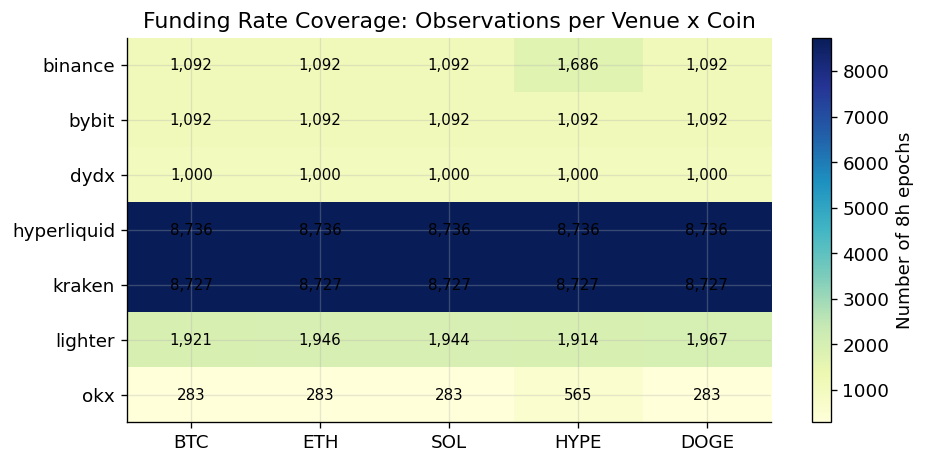

In [4]:
# Time coverage heatmap: funding observations by venue x coin
coverage = (
    funding.group_by(["venue", "coin"])
    .agg(pl.col("funding_rate").count().alias("n_obs"))
    .to_pandas()
    .pivot(index="venue", columns="coin", values="n_obs")
    .fillna(0)
    .astype(int)
)
coverage = coverage.reindex(columns=[c for c in COINS if c in coverage.columns])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(coverage.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
for i in range(len(coverage.index)):
    for j in range(len(coverage.columns)):
        ax.text(j, i, f"{coverage.values[i, j]:,}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="Number of 8h epochs")
ax.set_title("Funding Rate Coverage: Observations per Venue x Coin")
fig.tight_layout()
plt.show()

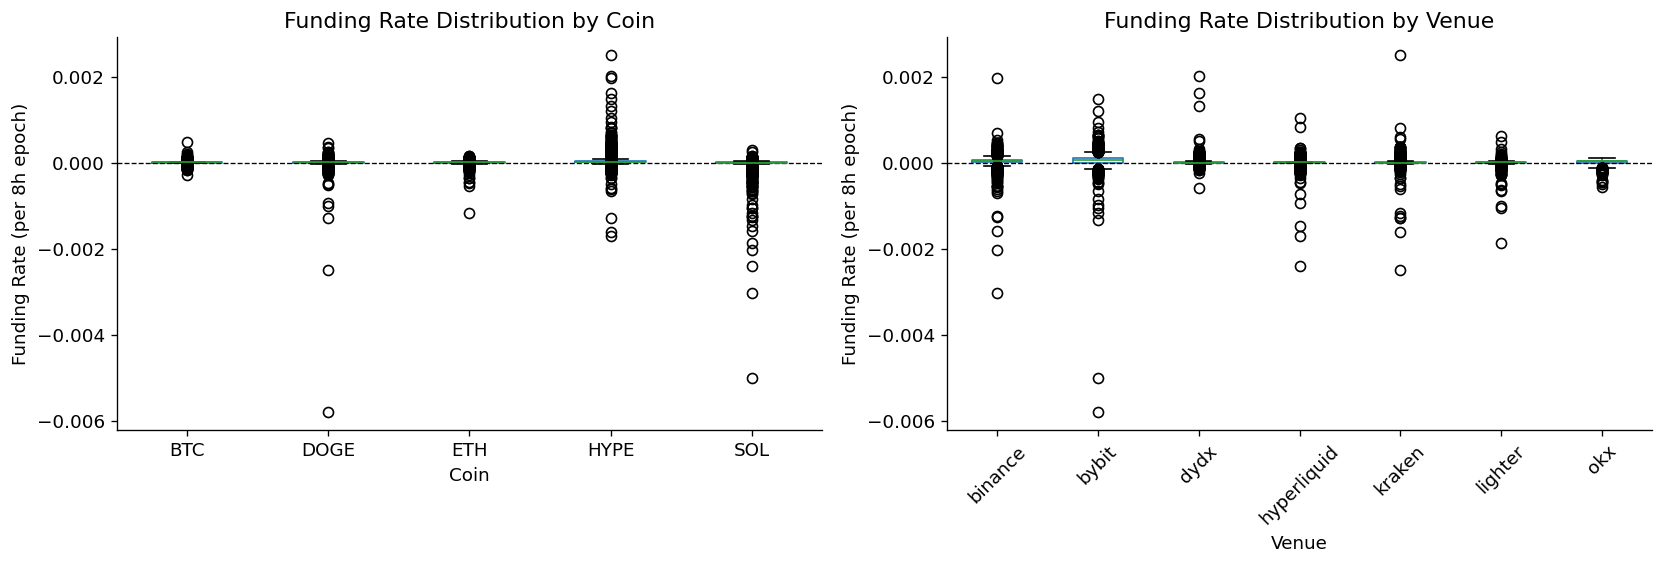

In [5]:
# Funding rate distributions: box plot by coin, then by venue
fund_pd = funding.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By coin
fund_pd.boxplot(column="funding_rate", by="coin", ax=axes[0], grid=False)
axes[0].set_title("Funding Rate Distribution by Coin")
axes[0].set_xlabel("Coin")
axes[0].set_ylabel("Funding Rate (per 8h epoch)")
axes[0].axhline(0, color="black", lw=0.8, ls="--")

# By venue
fund_pd.boxplot(column="funding_rate", by="venue", ax=axes[1], grid=False)
axes[1].set_title("Funding Rate Distribution by Venue")
axes[1].set_xlabel("Venue")
axes[1].set_ylabel("Funding Rate (per 8h epoch)")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("")
fig.tight_layout()
plt.show()

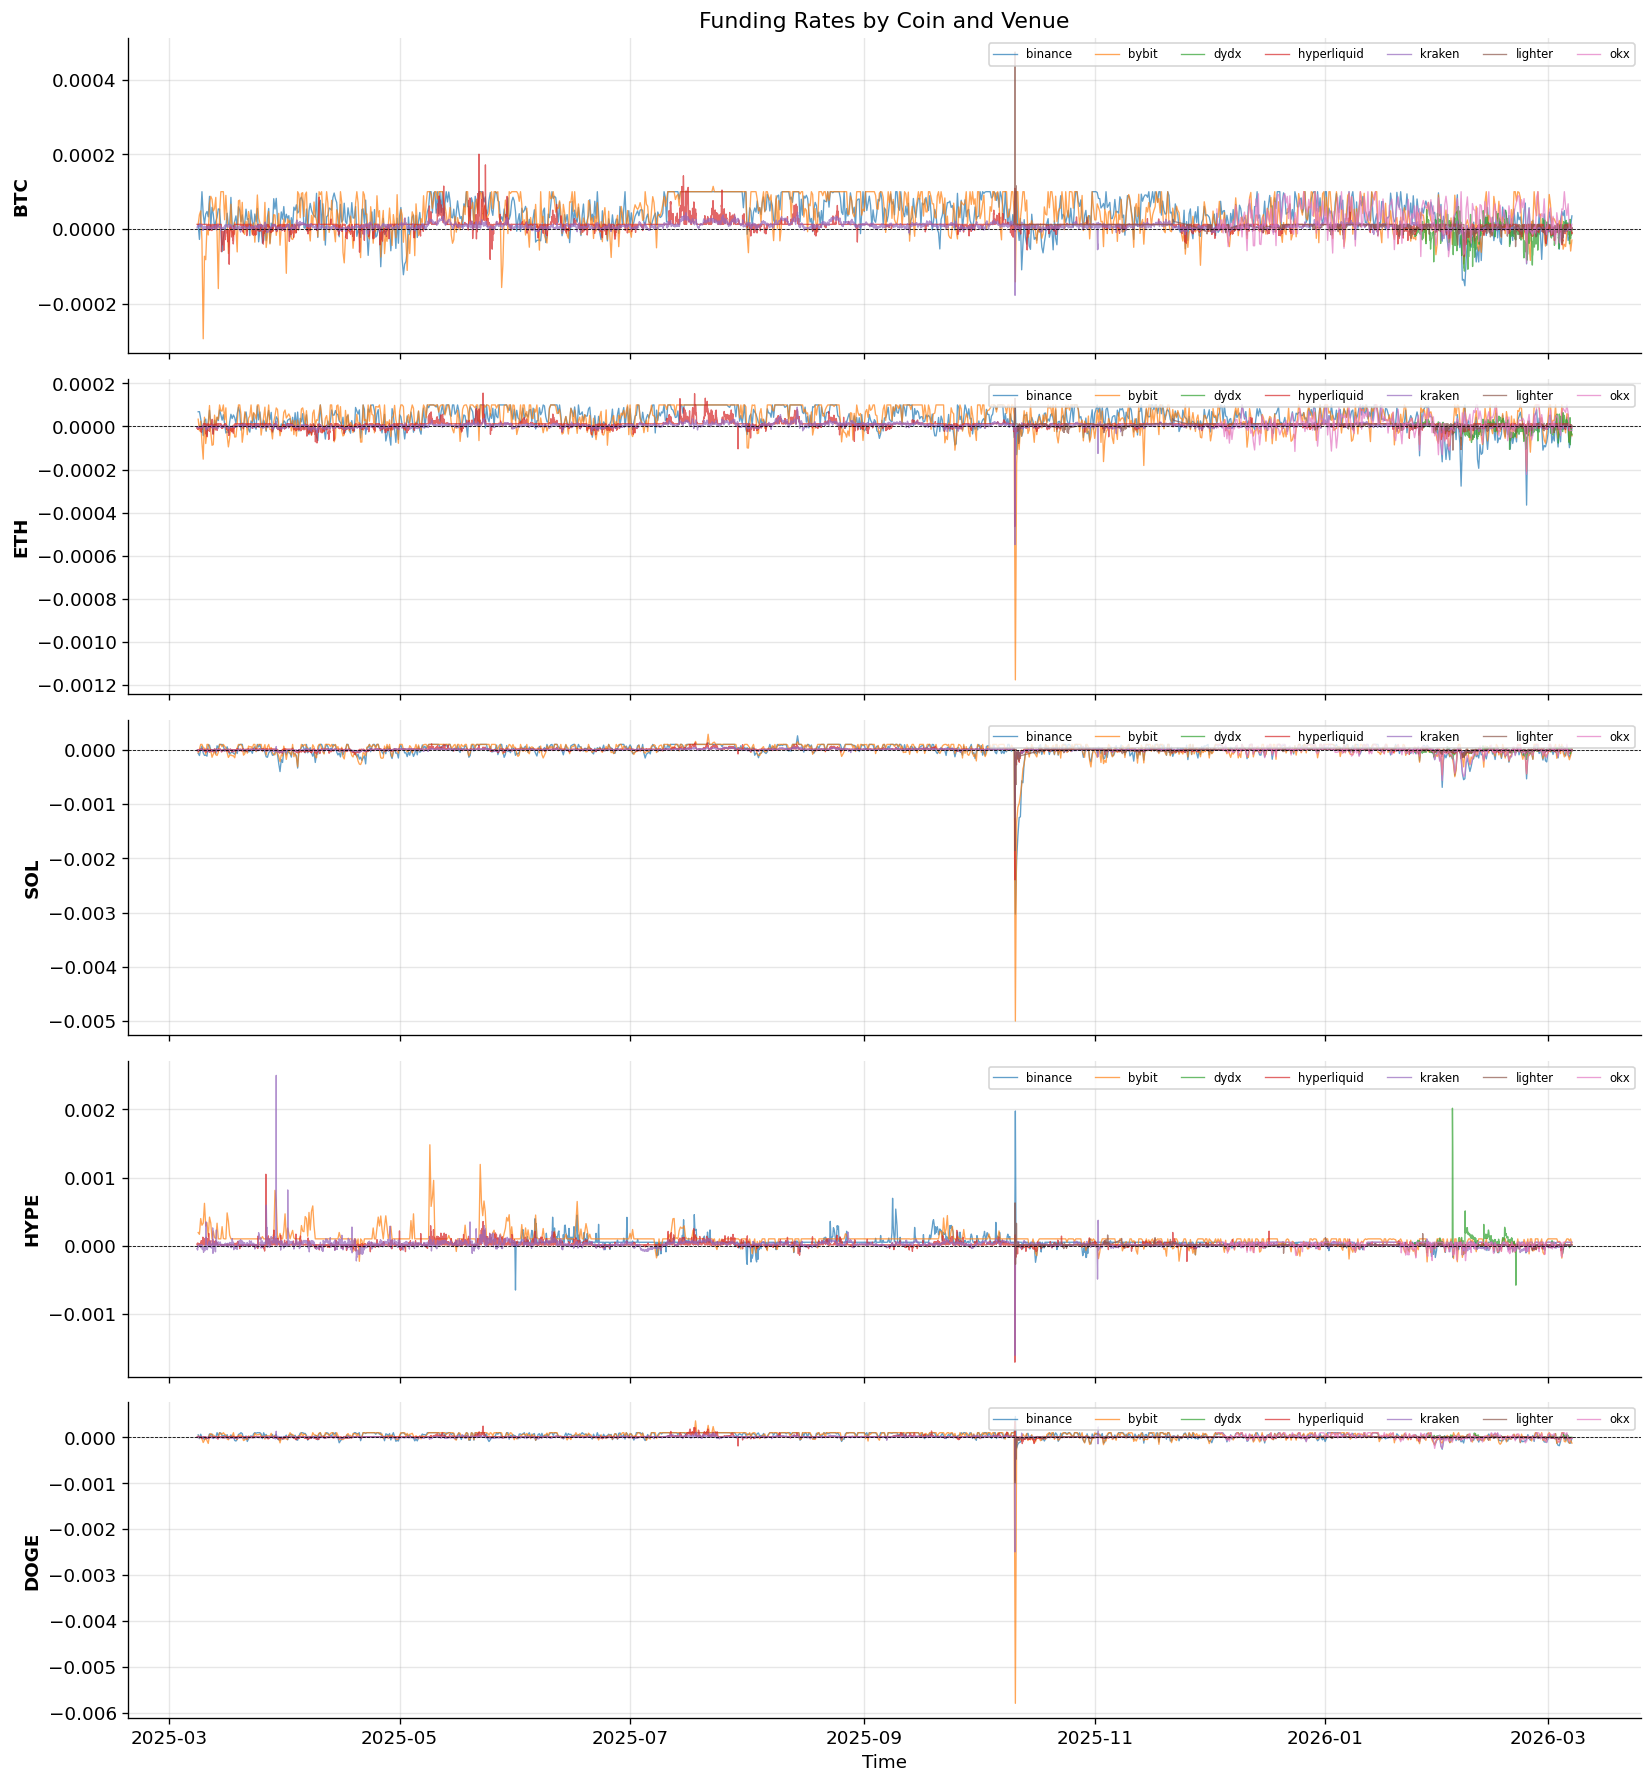

In [6]:
# Funding rate time series per coin, colored by venue
venues = funding["venue"].unique().sort().to_list()
venue_colors = dict(zip(venues, plt.cm.tab10.colors[: len(venues)]))

fig, axes = plt.subplots(len(COINS), 1, figsize=(14, 3 * len(COINS)), sharex=True)
for ax, coin in zip(axes, COINS):
    subset = funding.filter(pl.col("coin") == coin).sort("timestamp").to_pandas()
    for venue in venues:
        vdf = subset[subset["venue"] == venue]
        if vdf.empty:
            continue
        ax.plot(
            vdf["timestamp"],
            vdf["funding_rate"],
            label=venue,
            alpha=0.7,
            lw=0.8,
            color=venue_colors[venue],
        )
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel(coin, fontweight="bold")
    ax.legend(loc="upper right", fontsize=7, ncol=len(venues))
axes[-1].set_xlabel("Time")
axes[0].set_title("Funding Rates by Coin and Venue")
fig.tight_layout()
plt.show()

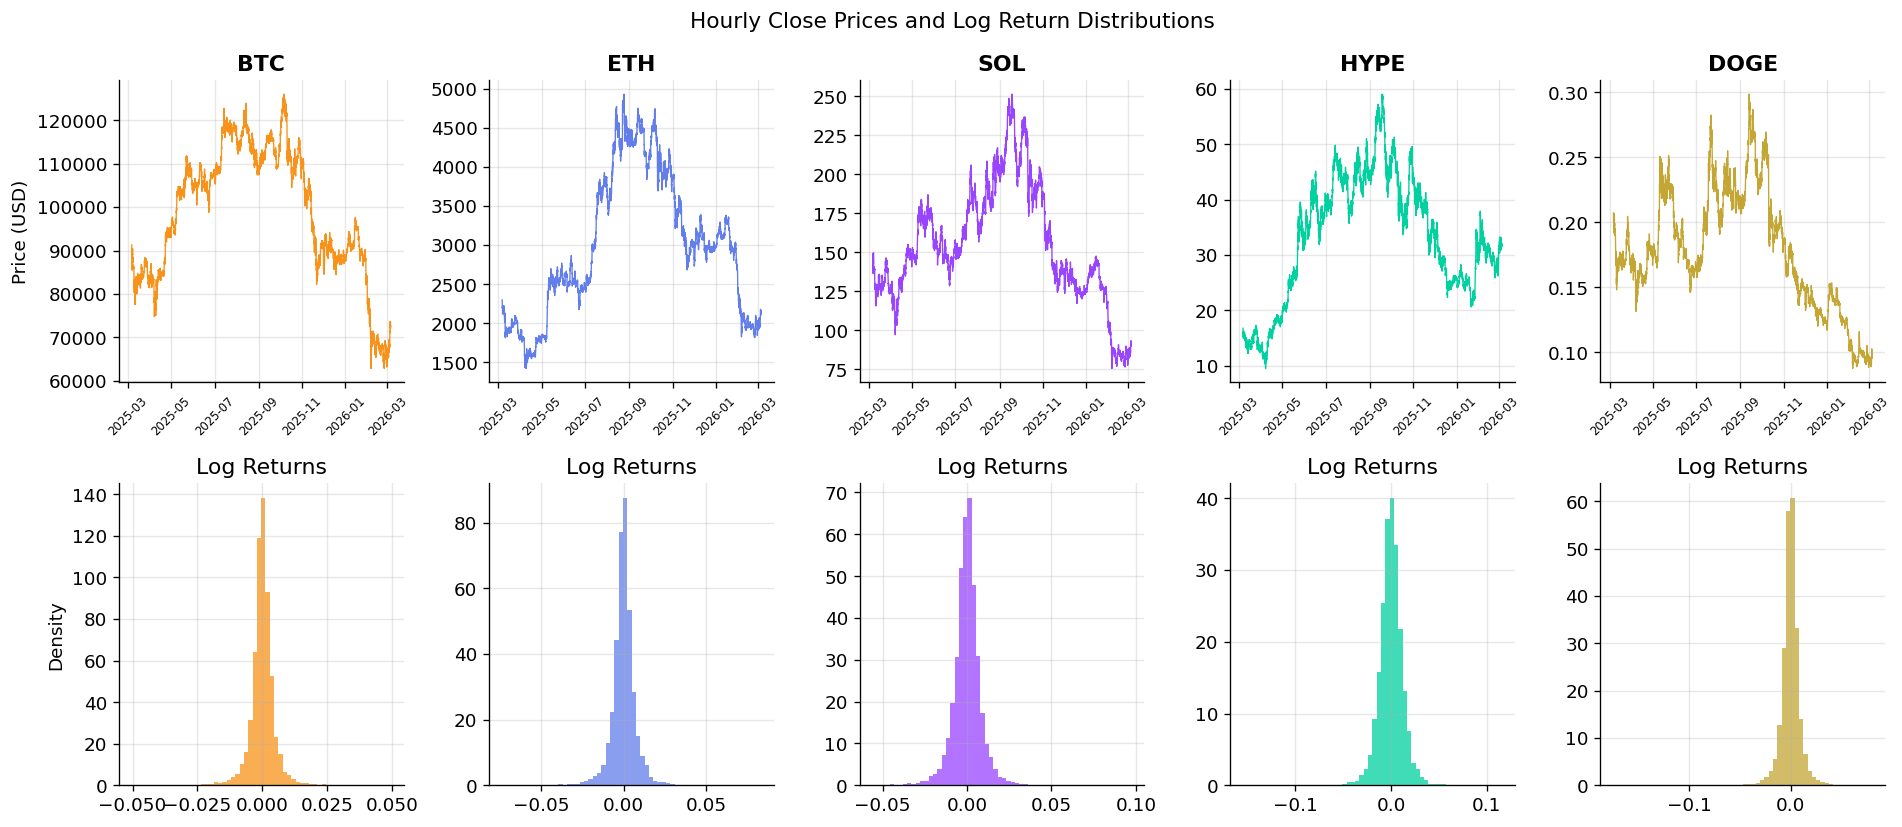

In [7]:
# Price time series (close) + log return histograms
# Use one representative venue per coin (first available)
prices = (
    candles.sort("timestamp")
    .group_by(["coin", "timestamp"])
    .agg(pl.col("c").mean().alias("close"))
    .sort("timestamp")
)

fig, axes = plt.subplots(2, len(COINS), figsize=(16, 7))
for j, coin in enumerate(COINS):
    pdf = prices.filter(pl.col("coin") == coin).to_pandas().set_index("timestamp")
    axes[0, j].plot(pdf.index, pdf["close"], color=COIN_COLORS[coin], lw=0.8)
    axes[0, j].set_title(coin, fontweight="bold")
    if j == 0:
        axes[0, j].set_ylabel("Price (USD)")
    axes[0, j].tick_params(axis="x", rotation=45, labelsize=7)

    log_ret = np.log(pdf["close"] / pdf["close"].shift(1)).dropna()
    axes[1, j].hist(log_ret, bins=60, color=COIN_COLORS[coin], alpha=0.75, density=True)
    axes[1, j].set_title(f"Log Returns")
    if j == 0:
        axes[1, j].set_ylabel("Density")

fig.suptitle("Hourly Close Prices and Log Return Distributions", fontsize=13)
fig.tight_layout()
plt.show()

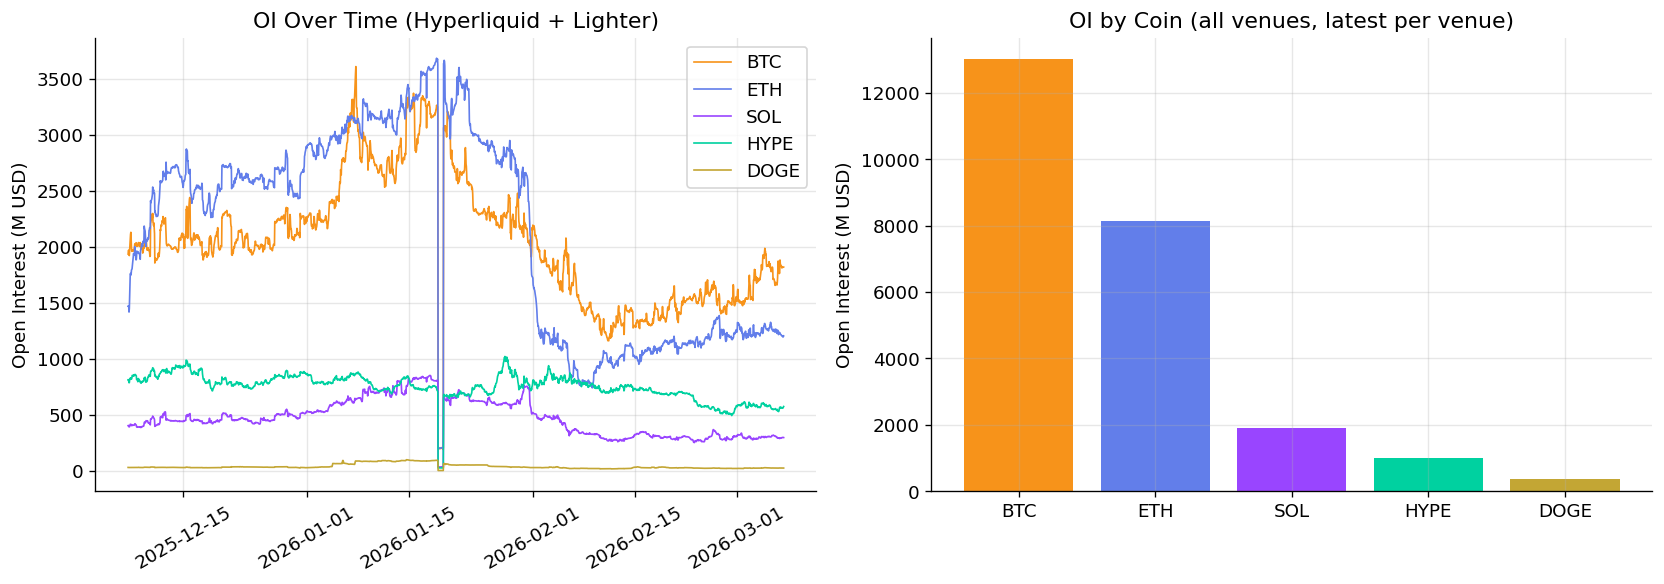

In [8]:
# Open interest time series + total OI bar chart
# Time series uses only venues with continuous history (Hyperliquid, Lighter).
# Bar chart uses the latest snapshot across all venues.
oi_hist = oi.filter(pl.col("venue").is_in(["hyperliquid", "lighter"])).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series (continuous venues only)
for coin in COINS:
    sub = oi_hist[oi_hist["coin"] == coin].groupby("timestamp")["oi_usd"].sum()
    if sub.empty:
        continue
    axes[0].plot(sub.index, sub.values / 1e6, label=coin, color=COIN_COLORS[coin], lw=1)
axes[0].set_ylabel("Open Interest (M USD)")
axes[0].set_title("OI Over Time (Hyperliquid + Lighter)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Bar chart: total OI by coin across all venues (latest snapshot per venue)
latest_oi = (
    oi.sort("timestamp")
    .group_by(["venue", "coin"])
    .last()
    .group_by("coin")
    .agg(pl.col("oi_usd").sum())
    .sort("oi_usd", descending=True)
    .to_pandas()
)
bar_colors = [COIN_COLORS.get(c, "gray") for c in latest_oi["coin"]]
axes[1].bar(latest_oi["coin"], latest_oi["oi_usd"] / 1e6, color=bar_colors)
axes[1].set_ylabel("Open Interest (M USD)")
axes[1].set_title("OI by Coin (all venues, latest per venue)")

fig.tight_layout()
plt.show()

In [9]:
# Cross-dataset summary: OI concentration, funding extremes
# Use latest snapshot per (venue, coin) to get full cross-venue OI
print("=== OI Concentration (latest per venue) ===")
latest_oi_full = (
    oi.sort("timestamp")
    .group_by(["venue", "coin"])
    .last()
    .group_by("coin")
    .agg(pl.col("oi_usd").sum())
    .sort("oi_usd", descending=True)
)
total_oi = latest_oi_full["oi_usd"].sum()
for row in latest_oi_full.iter_rows(named=True):
    pct = row["oi_usd"] / total_oi * 100
    print(f"  {row['coin']:5s}  ${row['oi_usd'] / 1e6:8.1f}M  ({pct:5.1f}%)")
print(f"  {'TOTAL':5s}  ${total_oi / 1e6:8.1f}M")

print("\n=== Funding Rate Extremes ===")
extremes = (
    funding.group_by(["venue", "coin"])
    .agg(
        [
            pl.col("funding_rate").mean().alias("mean_rate"),
            pl.col("funding_rate").std().alias("std_rate"),
            pl.col("funding_rate").min().alias("min_rate"),
            pl.col("funding_rate").max().alias("max_rate"),
        ]
    )
    .sort("std_rate", descending=True)
)
print(extremes.head(10))

=== OI Concentration (latest per venue) ===
  BTC    $ 13016.2M  ( 53.2%)
  ETH    $  8145.5M  ( 33.3%)
  SOL    $  1911.6M  (  7.8%)
  HYPE   $   997.7M  (  4.1%)
  DOGE   $   376.6M  (  1.5%)
  TOTAL  $ 24447.6M

=== Funding Rate Extremes ===
shape: (10, 6)
┌─────────┬──────┬───────────┬──────────┬───────────┬──────────┐
│ venue   ┆ coin ┆ mean_rate ┆ std_rate ┆ min_rate  ┆ max_rate │
│ ---     ┆ ---  ┆ ---       ┆ ---      ┆ ---       ┆ ---      │
│ str     ┆ str  ┆ f64       ┆ f64      ┆ f64       ┆ f64      │
╞═════════╪══════╪═══════════╪══════════╪═══════════╪══════════╡
│ bybit   ┆ SOL  ┆ 0.000006  ┆ 0.000189 ┆ -0.005    ┆ 0.000288 │
│ bybit   ┆ DOGE ┆ 0.000034  ┆ 0.000187 ┆ -0.0058   ┆ 0.000357 │
│ binance ┆ SOL  ┆ -0.000004 ┆ 0.000162 ┆ -0.003028 ┆ 0.000259 │
│ bybit   ┆ HYPE ┆ 0.000095  ┆ 0.00012  ┆ -0.000238 ┆ 0.001481 │
│ dydx    ┆ HYPE ┆ 0.00004   ┆ 0.000111 ┆ -0.00058  ┆ 0.002018 │
│ okx     ┆ SOL  ┆ -0.000018 ┆ 0.000101 ┆ -0.000563 ┆ 0.0001   │
│ binance ┆ HYPE ┆ 0.0000

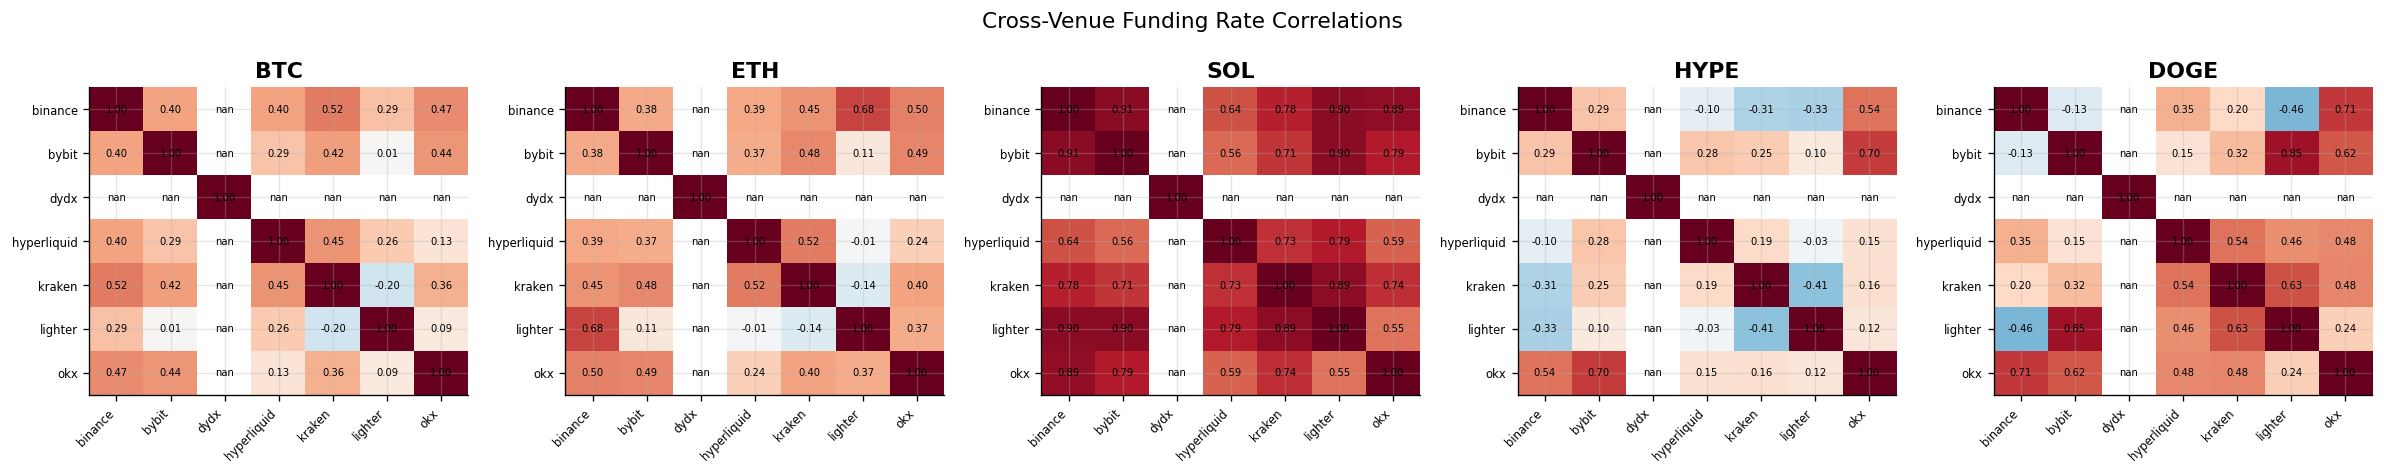

In [10]:
# Cross-venue funding rate correlation heatmap
# Pivot funding rates to (timestamp x venue) per coin and compute pairwise correlations
fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    sub = funding.filter(pl.col("coin") == coin).select("timestamp", "venue", "funding_rate")
    if sub.shape[0] == 0:
        ax.set_title(f"{coin}\n(no data)")
        continue
    pivoted = sub.to_pandas().pivot_table(index="timestamp", columns="venue", values="funding_rate")
    if pivoted.shape[1] < 2:
        ax.set_title(f"{coin}\n(single venue)")
        continue
    corr = pivoted.corr()
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index, fontsize=7)
    ax.set_title(coin, fontweight="bold")
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)

fig.suptitle("Cross-Venue Funding Rate Correlations", fontsize=13)
fig.tight_layout()
plt.show()

### EDA Takeaways

- **Funding rates** exhibit significant cross-venue dispersion, particularly for altcoins (HYPE, DOGE), creating carry opportunities.
- **BTC and ETH** dominate open interest (>80% combined), concentrating liquidation cascade risk in these two assets.
- **Coverage varies** across venues: not all exchanges list all coins, and some have shorter histories, requiring careful alignment in the carry strategy.
- **OI historical data** is available from Hyperliquid and Lighter via 0xArchive; CEX venues provide only point-in-time snapshots.

---
## 3. Jump-Diffusion Models

We calibrate two jump-diffusion models to hourly log returns:

**Merton (1976):** Gaussian jumps superimposed on GBM. The log-return density is a
Poisson-weighted mixture of normals, calibrated via two-stage heuristic + MLE.

$$dS/S = \mu\,dt + \sigma\,dW + J\,dN, \quad J \sim \mathcal{N}(\mu_J, \sigma_J^2)$$

**Kou (2002):** Double-exponential jumps that better capture the asymmetry between
up-jumps and down-jumps observed in crypto.

$$dS/S = \mu\,dt + \sigma\,dW + J\,dN, \quad f_J(x) = p\,\eta_1 e^{-\eta_1 x}\mathbf{1}_{x\ge0} + (1-p)\,\eta_2 e^{\eta_2 x}\mathbf{1}_{x<0}$$

In [11]:
# Merton jump-diffusion calibration: hourly log returns per coin
from funding_the_fall.models.merton import calibrate_merton, merton_log_density

# Compute hourly log returns per coin (average across venues)
prices = (
    candles.sort("timestamp")
    .group_by(["coin", "timestamp"])
    .agg(pl.col("c").mean().alias("close"))
    .sort("timestamp")
)

returns_dict = {}
for coin in COINS:
    close = prices.filter(pl.col("coin") == coin).sort("timestamp")["close"].to_numpy()
    lr = np.diff(np.log(close))
    lr = lr[np.isfinite(lr)]
    returns_dict[coin] = lr

# Calibrate Merton for each coin
merton_results = {}
rows = []
for coin in COINS:
    m = calibrate_merton(returns_dict[coin], dt=1.0)
    merton_results[coin] = m
    rows.append(
        {
            "Coin": coin,
            "σ": f"{m.sigma:.5f}",
            "λ": f"{m.lam:.4f}",
            "μ_J": f"{m.mu_j:.5f}",
            "σ_J": f"{m.sigma_j:.5f}",
            "LL": f"{m.log_likelihood:.1f}",
            "AIC": f"{m.aic:.1f}",
            "BIC": f"{m.bic:.1f}",
        }
    )

pd.DataFrame(rows).style.hide(axis="index")

Coin,σ,λ,μ_J,σ_J,LL,AIC,BIC
BTC,0.00241,0.3094,-0.00030,0.00697,35906.9,-71803.7,-71768.4
ETH,0.00372,0.3711,-0.00035,0.01019,31758.6,-63507.2,-63471.8
SOL,0.00495,0.3318,-0.00069,0.01130,30310.8,-60611.6,-60576.2
HYPE,0.00887,0.2555,0.00058,0.01650,26484.8,-52959.5,-52924.1
DOGE,0.00509,0.3316,-0.00025,0.01297,29657.2,-59304.4,-59269.0


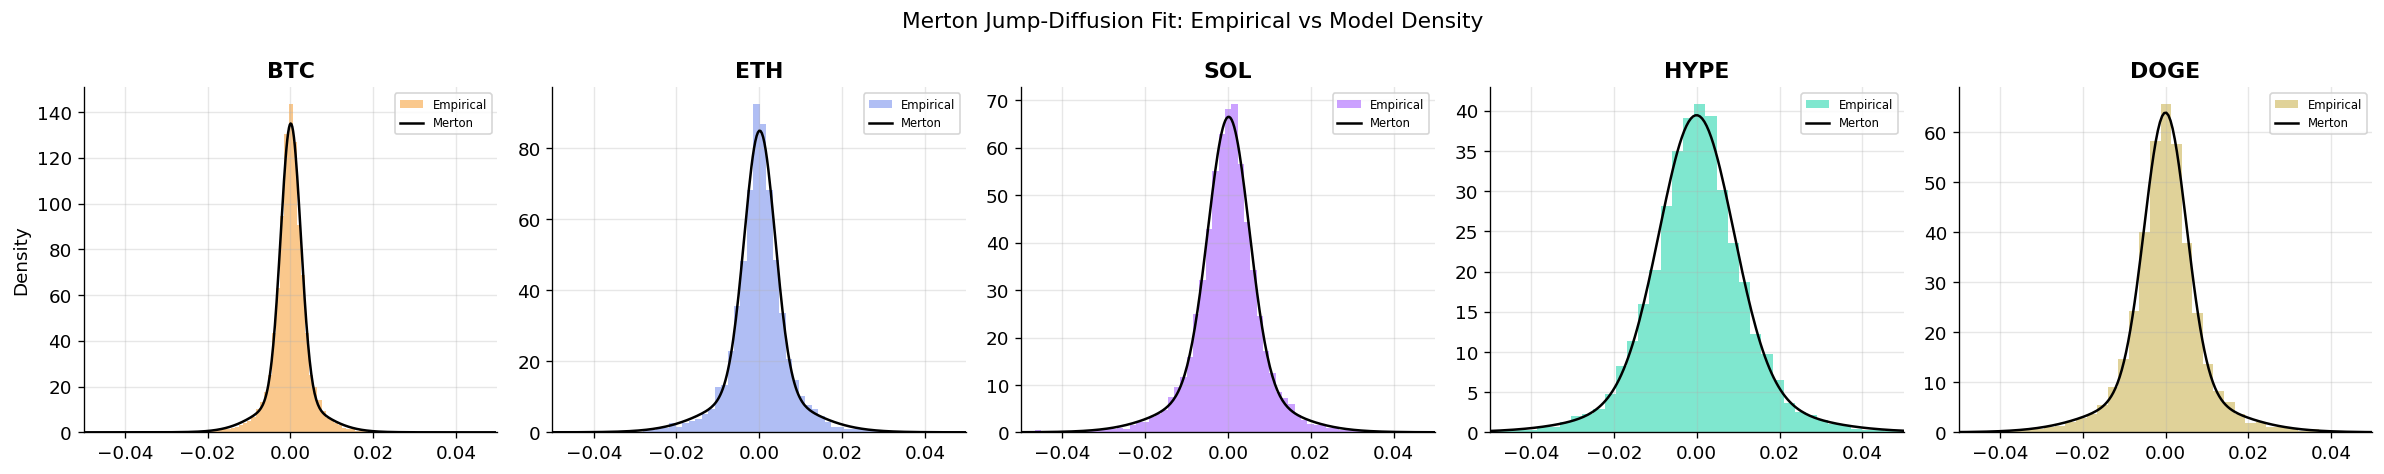

In [12]:
# Merton density overlay: empirical histogram vs fitted density per coin
fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    lr = returns_dict[coin]
    ax.hist(lr, bins=100, density=True, alpha=0.5, color=COIN_COLORS[coin], label="Empirical")
    x_grid = np.linspace(lr.min(), lr.max(), 500)
    log_d = merton_log_density(x_grid, merton_results[coin], dt=1.0)
    ax.plot(x_grid, np.exp(log_d), "k-", lw=1.5, label="Merton")
    ax.set_title(coin, fontweight="bold")
    ax.set_xlim(-0.05, 0.05)
    if coin == COINS[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=7)
fig.suptitle("Merton Jump-Diffusion Fit: Empirical vs Model Density", fontsize=13)
fig.tight_layout()
plt.show()

### Kou Double-Exponential Model

The Kou model's double-exponential jump distribution introduces an additional degree of
freedom: the probability $p$ of an up-jump and separate decay rates $\eta_1, \eta_2$
for positive and negative jumps, capturing the empirical asymmetry in crypto returns.

In [13]:
# Kou double-exponential calibration
from funding_the_fall.models.kou import calibrate_kou, kou_log_density

kou_results = {}
rows = []
for coin in COINS:
    k = calibrate_kou(returns_dict[coin], dt=1.0)
    kou_results[coin] = k
    rows.append(
        {
            "Coin": coin,
            "σ": f"{k.sigma:.5f}",
            "λ": f"{k.lam:.4f}",
            "p": f"{k.p:.3f}",
            "η₁": f"{k.eta1:.2f}",
            "η₂": f"{k.eta2:.2f}",
            "LL": f"{k.log_likelihood:.1f}",
            "AIC": f"{k.aic:.1f}",
            "BIC": f"{k.bic:.1f}",
        }
    )

pd.DataFrame(rows).style.hide(axis="index")

Coin,σ,λ,p,η₁,η₂,LL,AIC,BIC
BTC,0.00313,0.0887,0.445,65.69,63.80,35643.7,-71275.4,-71232.9
ETH,0.00514,0.0828,0.435,40.12,40.52,31483.3,-62954.5,-62912.1
SOL,0.00647,0.0591,0.418,36.03,35.51,30106.8,-60201.7,-60159.2
HYPE,0.01078,0.0300,0.540,23.22,23.53,26373.0,-52734.0,-52691.6
DOGE,0.00664,0.0792,0.489,34.10,32.32,29392.4,-58772.8,-58730.3


### Model Comparison

We compare Merton and Kou fits using AIC and BIC. Merton is uniformly preferred: the
Kou model's extra parameter ($p$, the up-jump probability) is not justified by the data.
At hourly frequency, $\eta_1 \approx \eta_2$ across all coins, indicating no strong
tail asymmetry — jumps are roughly symmetric. This is consistent with the high-frequency
regime where microstructure noise dominates directional jump asymmetry.

We proceed with Merton parameters for the jump-weighted risk score, which feeds into
cascade short sizing in the allocation module.

Coin Merton BIC  Kou BIC   ΔBIC Preferred
 BTC   -71768.4 -71232.9 -535.5    MERTON
 ETH   -63471.8 -62912.1 -559.7    MERTON
 SOL   -60576.2 -60159.2 -417.0    MERTON
HYPE   -52924.1 -52691.6 -232.6    MERTON
DOGE   -59269.0 -58730.3 -538.7    MERTON


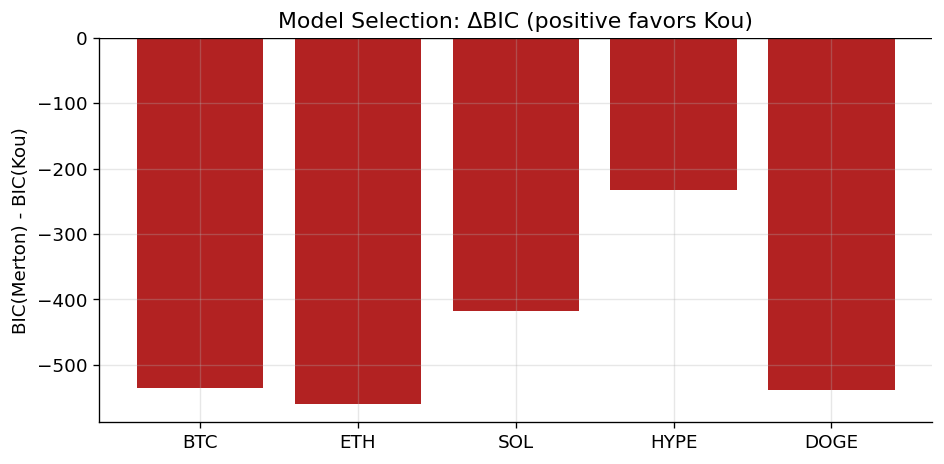

In [14]:
# AIC/BIC model comparison: Merton vs Kou
from funding_the_fall.models.compare import compare_all_tokens

comparisons = compare_all_tokens(returns_dict, dt=1.0)

rows = []
for coin in COINS:
    c = comparisons[coin]
    rows.append(
        {
            "Coin": coin,
            "Merton BIC": f"{c.merton.bic:.1f}",
            "Kou BIC": f"{c.kou.bic:.1f}",
            "ΔBIC": f"{c.bic_delta:.1f}",
            "Preferred": c.preferred.upper(),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

# BIC delta bar chart
fig, ax = plt.subplots(figsize=(8, 4))
deltas = [comparisons[c].bic_delta for c in COINS]
colors = ["steelblue" if d > 0 else "firebrick" for d in deltas]
ax.bar(COINS, deltas, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("BIC(Merton) - BIC(Kou)")
ax.set_title("Model Selection: ΔBIC (positive favors Kou)")
fig.tight_layout()
plt.show()

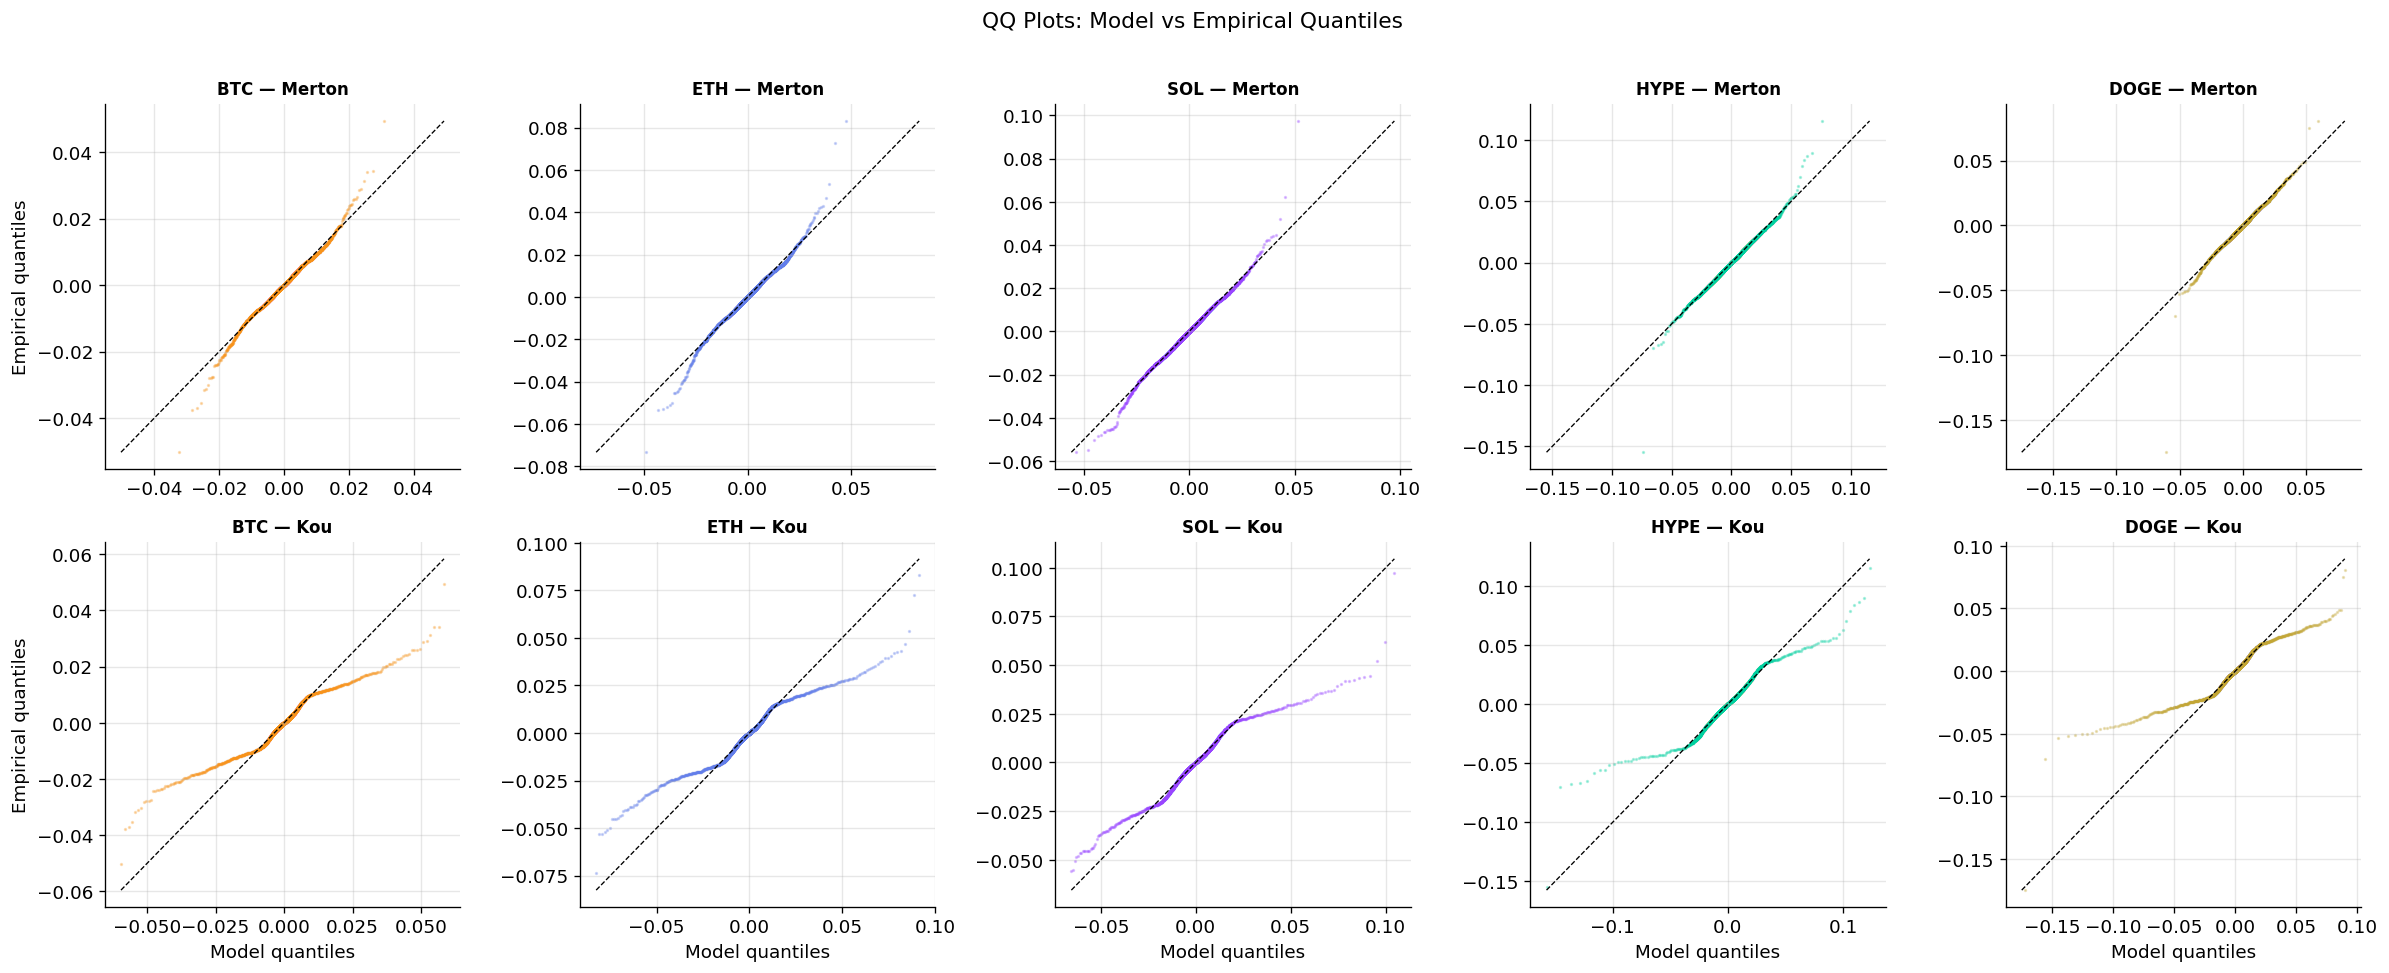

In [15]:
# QQ plots: Merton vs Kou tail fit per coin
from scipy.stats import norm

fig, axes = plt.subplots(2, len(COINS), figsize=(4 * len(COINS), 8))
for j, coin in enumerate(COINS):
    lr = np.sort(returns_dict[coin])
    n = len(lr)
    empirical_quantiles = (np.arange(1, n + 1) - 0.5) / n

    # Merton: invert CDF numerically from density on a fine grid
    x_fine = np.linspace(lr.min() - 0.01, lr.max() + 0.01, 5000)
    m_density = np.exp(merton_log_density(x_fine, merton_results[coin], dt=1.0))
    m_cdf = np.cumsum(m_density) * (x_fine[1] - x_fine[0])
    m_cdf = m_cdf / m_cdf[-1]  # normalize
    m_quantiles = np.interp(empirical_quantiles, m_cdf, x_fine)

    k_density = np.exp(kou_log_density(x_fine, kou_results[coin], dt=1.0))
    k_cdf = np.cumsum(k_density) * (x_fine[1] - x_fine[0])
    k_cdf = k_cdf / k_cdf[-1]
    k_quantiles = np.interp(empirical_quantiles, k_cdf, x_fine)

    # Merton QQ
    axes[0, j].scatter(m_quantiles, lr, s=1, alpha=0.3, color=COIN_COLORS[coin])
    lims = [min(lr.min(), m_quantiles.min()), max(lr.max(), m_quantiles.max())]
    axes[0, j].plot(lims, lims, "k--", lw=0.8)
    axes[0, j].set_title(f"{coin} — Merton", fontweight="bold", fontsize=10)
    if j == 0:
        axes[0, j].set_ylabel("Empirical quantiles")

    # Kou QQ
    axes[1, j].scatter(k_quantiles, lr, s=1, alpha=0.3, color=COIN_COLORS[coin])
    lims = [min(lr.min(), k_quantiles.min()), max(lr.max(), k_quantiles.max())]
    axes[1, j].plot(lims, lims, "k--", lw=0.8)
    axes[1, j].set_title(f"{coin} — Kou", fontweight="bold", fontsize=10)
    if j == 0:
        axes[1, j].set_ylabel("Empirical quantiles")
    axes[1, j].set_xlabel("Model quantiles")

fig.suptitle("QQ Plots: Model vs Empirical Quantiles", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

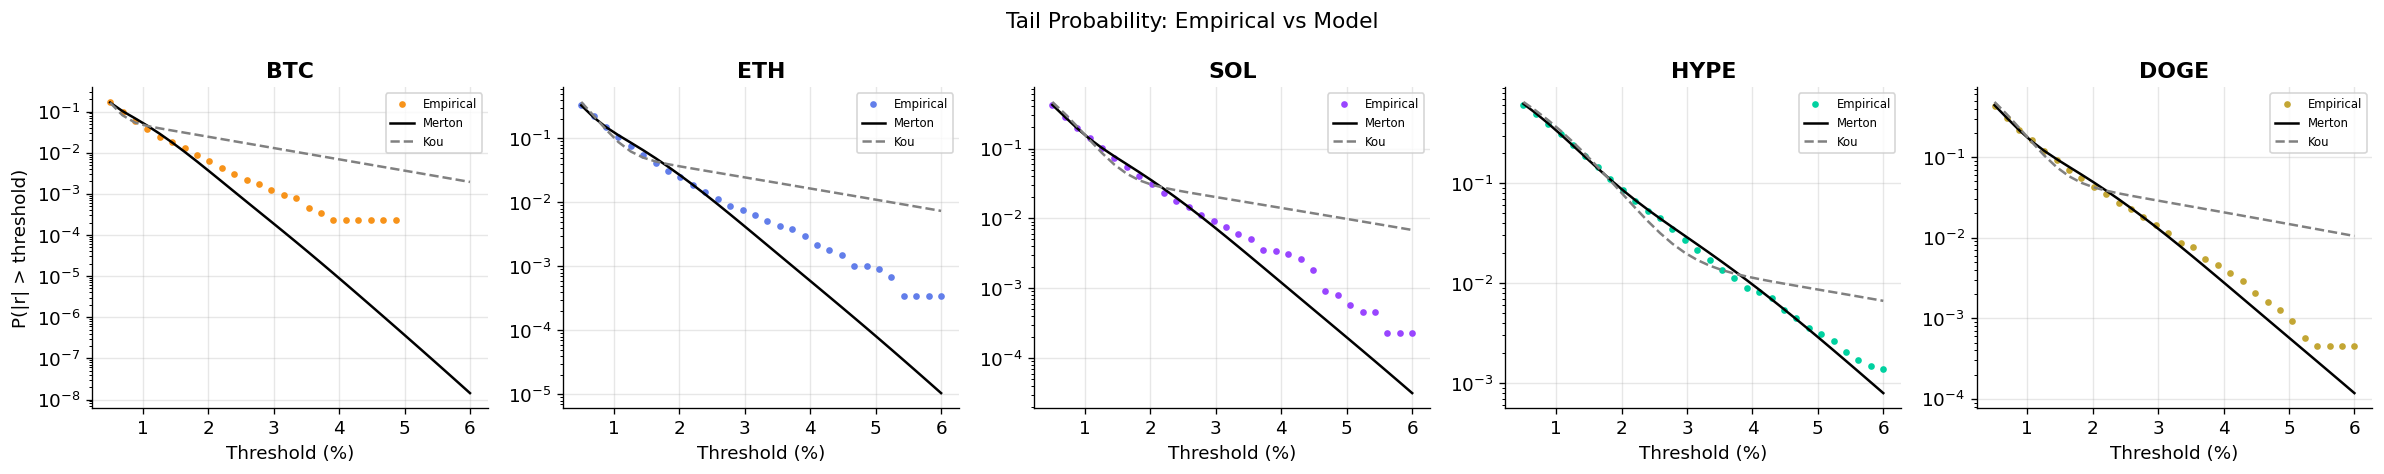

In [16]:
# Tail probability comparison: P(|r| > threshold) empirical vs Merton vs Kou
thresholds = np.linspace(0.005, 0.06, 30)

fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    lr = returns_dict[coin]
    n = len(lr)

    # Empirical tail probabilities
    emp_tail = [np.mean(np.abs(lr) > t) for t in thresholds]

    # Model tail probabilities via numerical CDF
    x_fine = np.linspace(-0.15, 0.15, 8000)
    dx = x_fine[1] - x_fine[0]

    m_pdf = np.exp(merton_log_density(x_fine, merton_results[coin], dt=1.0))
    m_cdf_vals = np.cumsum(m_pdf) * dx
    m_cdf_vals = m_cdf_vals / m_cdf_vals[-1]
    m_tail = [
        float(np.interp(-t, x_fine, m_cdf_vals) + 1 - np.interp(t, x_fine, m_cdf_vals))
        for t in thresholds
    ]

    k_pdf = np.exp(kou_log_density(x_fine, kou_results[coin], dt=1.0))
    k_cdf_vals = np.cumsum(k_pdf) * dx
    k_cdf_vals = k_cdf_vals / k_cdf_vals[-1]
    k_tail = [
        float(np.interp(-t, x_fine, k_cdf_vals) + 1 - np.interp(t, x_fine, k_cdf_vals))
        for t in thresholds
    ]

    ax.semilogy(thresholds * 100, emp_tail, "o", ms=3, color=COIN_COLORS[coin], label="Empirical")
    ax.semilogy(thresholds * 100, m_tail, "-", lw=1.5, color="black", label="Merton")
    ax.semilogy(thresholds * 100, k_tail, "--", lw=1.5, color="gray", label="Kou")
    ax.set_title(coin, fontweight="bold")
    ax.set_xlabel("Threshold (%)")
    if coin == COINS[0]:
        ax.set_ylabel("P(|r| > threshold)")
    ax.legend(fontsize=7)

fig.suptitle("Tail Probability: Empirical vs Model", fontsize=13)
fig.tight_layout()
plt.show()

### Jump-Weighted Risk Score

The jump-weighted risk score combines calibrated Merton tail probabilities with cascade
amplification via numerical integration:

$$\text{Expected amplified loss} = \int_0^{0.50} f(-\delta) \cdot \delta \cdot A(\delta)\, d\delta$$

where $f$ is the Merton density and $A(\delta)$ is the cascade amplification factor.
Because the cascade is binary (no amplification below the critical shock, catastrophic above
it), the integral effectively weights the probability mass beyond each coin's critical shock.
Coins with lower critical shocks (BTC, ETH at 2%) accumulate more probability-weighted cascade
loss than coins with higher thresholds (DOGE at 9.5%).

The **cascade multiplier** — the ratio of amplified to baseline expected loss — measures how
much cascade fragility compounds jump risk for each coin. OI is scoped to depth-measured venues
(Hyperliquid + Lighter) for consistency.

In [17]:
# Jump-weighted risk with tiered leverage and per-coin measured depth
# Scoped to venue-matched OI (Hyperliquid + Lighter) for consistency with depth data
from funding_the_fall.models.risk import jump_weighted_risk_all_coins

oi_for_risk = oi.filter(pl.col("venue").is_in(["hyperliquid", "lighter"]))

jwr = jump_weighted_risk_all_coins(
    merton_results,
    oi_for_risk,
    dt=1.0,
    depth_per_coin=measured_depth,
    tiered=True,
)

rows = []
for coin in COINS:
    if coin not in jwr:
        continue
    r = jwr[coin]
    rows.append(
        {
            "Coin": coin,
            "Baseline Loss": f"{r['baseline_loss']:.4e}",
            "Amplified Loss": f"{r['amplified_loss']:.4e}",
            "Cascade Mult.": f"{r['cascade_multiplier']:.1f}x",
            "P(≤-5%)": f"{r['tail_probability_5pct']:.2e}",
            "A(5%)": f"{r['amplification_at_5pct']:.2f}",
        }
    )
pd.DataFrame(rows).style.hide(axis="index")

Coin,Baseline Loss,Amplified Loss,Cascade Mult.,P(≤-5%),A(5%)
BTC,8.6596e-04,8.6641e-04,1.0x,5.81e-08,20.00
ETH,1.7878e-03,1.9751e-03,1.1x,1.86e-05,20.00
SOL,2.2543e-03,2.4296e-03,1.1x,5.37e-05,20.00
HYPE,3.9524e-03,5.6264e-03,1.4x,7.07e-04,20.00
DOGE,2.5013e-03,2.5016e-03,1.0x,1.48e-04,1.00


---
## 4. Liquidation Cascade Simulator

### Methodology

The cascade simulator models the feedback loop between forced liquidations and price impact:

1. An exogenous shock $\delta_0$ drops the price by a fraction.
2. Long positions whose remaining equity (margin $-$ notional $\times \delta$) falls below
   maintenance margin are force-closed.
3. The liquidated notional hits the orderbook, causing additional price impact via the
   square-root law: $\Delta p/p = \sqrt{V_{\text{liq}} / D}$.
4. Repeat until no new liquidations trigger.

The **amplification factor** $A(\delta) = \delta_{\text{eff}} / \delta_0$ captures how much
the feedback loop magnifies the initial shock.

**Liquidation mechanics.** A perp position at leverage $L$ posts margin $= N/L$ (where $N$
is notional). After a price drop $\delta$, remaining equity is $N/L - N\delta$. Liquidation
occurs when this drops below the maintenance margin ($\approx 0.5\%$ of notional):

$$\delta_{\text{liq}} = \frac{1}{L} - m \approx \frac{1}{L}$$

So 5x leverage liquidates at $\sim$ 20%, 50x at $\sim$ 2%, and 125x at $\sim$ 0.8%.

**Leverage tiers.** We model heterogeneous leverage using per-venue maximum leverage data
from exchange APIs. For each (venue, coin) pair, OI is split: 75% at conservative leverage
(3x), 20% at moderate (max/3), and 5% at the higher of the venue's max or 20x, whichever
is less. This reflects that the vast majority of perp volume is at modest leverage; only a
small tail uses extreme leverage.

**Depth and risk score.** We measure 1% bid-side orderbook depth from Hyperliquid and Lighter
via 0xArchive snapshots and scope OI to these same two venues. The cascade risk score is
based on the **OI-to-depth ratio**, which genuinely varies over time as open interest grows and
shrinks:

$$\text{risk\_score} = 1 - \exp\!\left(-\frac{\text{OI}/\text{depth}}{k}\right), \quad k = 200$$

This captures the structural fragility that drives cascades: when OI is large relative to
orderbook depth, any forced liquidation overwhelms standing liquidity. The reference ratio
$k=200$ is calibrated so that the median crypto market condition produces a moderate risk
score ($\sim$ 0.5–0.6), with scores declining toward 0 during low-OI periods and saturating
near 1 during OI spikes.

### Price Impact and Literature

**Square-root price impact.**
We model forced-selling impact as $\Delta p / p = \sqrt{V / D}$ where $V$ is the
liquidation volume and $D$ is the 1% orderbook depth. This functional form is
well-established in the market microstructure literature:
- Almgren & Chriss (2001) derive it from optimal execution under linear temporary impact.
- Jusselin & Rosenbaum (2018) show that no-arbitrage constraints imply power-law impact
  with exponent $\approx 0.5$, consistent with square-root.
- Empirical studies (Bouchaud et al., 2018) find $\Delta p \propto V^{0.4\text{-}0.6}$ across
  equity and crypto markets.


With OI-to-depth ratios of 16–330x, even the 20% of OI at the highest leverage
tier produces forced selling that overwhelms the standing orderbook by orders of magnitude.
For example, BTC on Lighter has \$105M OI; the 50x tier alone is \$21M notional, but the
standing 1% depth is only \$1.3M. The square-root impact of liquidating \$21M against \$1.3M is
$\sqrt{21/1.3} \approx 4\times$, immediately crashing price and triggering all remaining tiers.

This binary behavior is consistent with real crypto cascade events (e.g., the May 2021 BTC
crash, the November 2022 FTX collapse), where cascades are sudden, non-linear, and complete
once triggered. The model captures this structural fragility.

In [18]:
# Orderbook depth and OI summary (scoped to venues with depth data)
oi_matched = oi.filter(pl.col("venue").is_in(["hyperliquid", "lighter"]))

print("=== Measured 1% Bid-Side Depth (USD) ===")
for row in depth_df.sort(["coin", "venue"]).to_pandas().itertuples():
    print(f"  {row.venue:12s} {row.coin:5s}  ${row.bid_depth_usd / 1e6:.2f}M")

print(f"\n=== OI Scoped to Depth-Measured Venues ===")
oi_latest = oi_matched.sort("timestamp").group_by(["venue", "coin"]).last()
for coin in COINS:
    coin_oi = oi_latest.filter(pl.col("coin") == coin)["oi_usd"].sum()
    depth = measured_depth.get(coin, 0)
    ratio = coin_oi / depth if depth > 0 else float("inf")
    print(
        f"  {coin:5s}  OI=${coin_oi / 1e6:>8.1f}M   depth=${depth / 1e6:.1f}M   OI/depth={ratio:>5.0f}x"
    )

# Show leverage tiers for a sample (Lighter BTC)
from funding_the_fall.models.cascade import _venue_tiers

print(f"\n=== Sample Leverage Tiers ===")
for venue in ["hyperliquid", "lighter"]:
    tiers = _venue_tiers(venue, "BTC")
    lev_str = ", ".join(f"{w:.0%} at {l:.0f}x" for l, w in tiers)
    max_lev = MAX_LEVERAGE.get((venue, "BTC"), 10)
    print(f"  {venue} BTC (max {max_lev}x): {lev_str}")

=== Measured 1% Bid-Side Depth (USD) ===
  hyperliquid  BTC    $4.21M
  lighter      BTC    $1.31M
  hyperliquid  DOGE   $0.08M
  lighter      DOGE   $1.44M
  hyperliquid  ETH    $13.46M
  lighter      ETH    $1.44M
  hyperliquid  HYPE   $0.10M
  lighter      HYPE   $0.45M
  hyperliquid  SOL    $0.46M
  lighter      SOL    $3.81M

=== OI Scoped to Depth-Measured Venues ===
  BTC    OI=$  1818.3M   depth=$5.5M   OI/depth=  329x
  ETH    OI=$  1203.8M   depth=$14.9M   OI/depth=   81x
  SOL    OI=$   295.9M   depth=$4.3M   OI/depth=   69x
  HYPE   OI=$   573.2M   depth=$0.5M   OI/depth= 1048x
  DOGE   OI=$    23.7M   depth=$1.5M   OI/depth=   16x

=== Sample Leverage Tiers ===
  hyperliquid BTC (max 40x): 75% at 3x, 20% at 13x, 5% at 20x
  lighter BTC (max 50x): 75% at 3x, 20% at 17x, 5% at 20x


=== Per-Coin Cascade Risk (tiered leverage, venue-matched) ===

Coin    OI/Depth  Risk Score  Crit. Shock   A(5%)
--------------------------------------------------
BTC       329.4x       0.807         5.0%   20.0x
ETH        80.8x       0.332         4.5%   20.0x
SOL        69.3x       0.293         5.0%   20.0x
HYPE     1048.4x       0.995         5.0%   20.0x
DOGE       15.6x       0.075         9.5%    1.0x


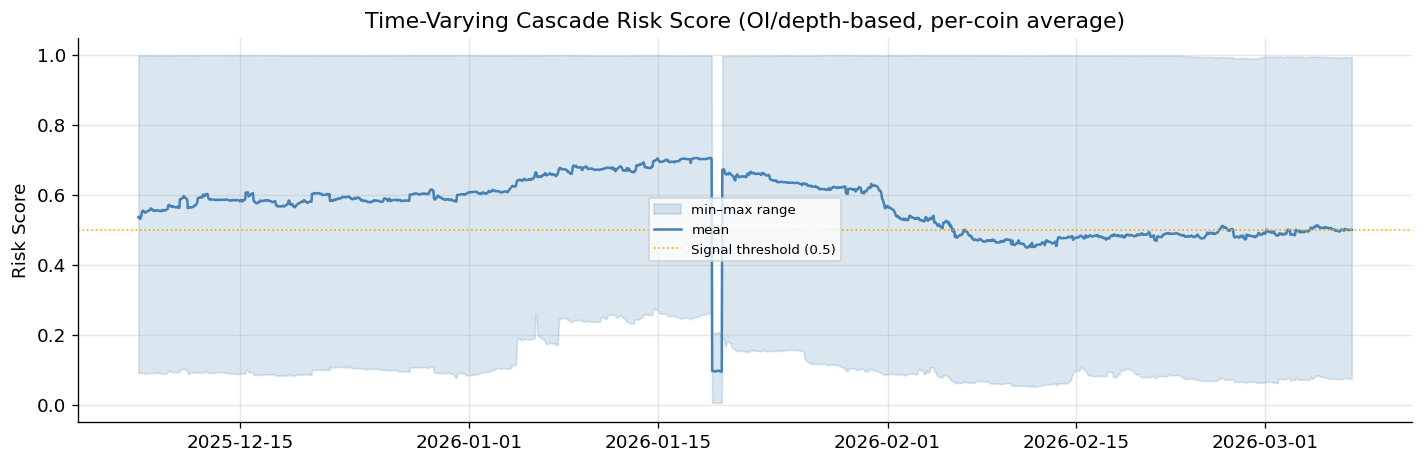


Mean risk score: min=0.095  median=0.583  max=0.706


In [19]:
# Per-coin risk signals with tiered leverage, venue-matched OI
signals = per_coin_risk_signals(oi_matched, depth_per_coin=measured_depth)

print("=== Per-Coin Cascade Risk (tiered leverage, venue-matched) ===\n")
print(f"{'Coin':5s}  {'OI/Depth':>9s}  {'Risk Score':>10s}  {'Crit. Shock':>11s}  {'A(5%)':>6s}")
print("-" * 50)
for coin in COINS:
    s = signals.get(coin, {})
    crit = s.get("critical_shock")
    crit_str = f"{crit:.1%}" if crit else "none"
    ratio = s.get("oi_depth_ratio", 0)
    print(
        f"{coin:5s}  {ratio:>8.1f}x  {s.get('risk_score', 0):>10.3f}  "
        f"{crit_str:>11s}  {s.get('amplification_at_5pct', 0):>5.1f}x"
    )

# Time-varying risk: per-coin scores averaged across coins at each timestamp
# Cascades are per-coin (not cross-coin), so aggregate = mean of per-coin scores
total_depth = sum(measured_depth.values()) / max(len(measured_depth), 1)
oi_timestamps = oi_matched["timestamp"].unique().sort().to_list()
risk_scores = []
for ts in oi_timestamps:
    snap = oi_matched.filter(pl.col("timestamp") == ts)
    coin_scores = []
    for coin in COINS:
        coin_snap = snap.filter(pl.col("coin") == coin)
        if coin_snap.is_empty():
            continue
        pos_t = build_positions_tiered(coin_snap)
        if not pos_t:
            continue
        depth = measured_depth.get(coin, total_depth)
        sig = cascade_risk_signal(pos_t, current_price=1.0, orderbook_depth_usd=depth)
        coin_scores.append(sig["risk_score"])
    if coin_scores:
        risk_scores.append(
            {
                "timestamp": ts,
                "risk_score": np.mean(coin_scores),
                "max_risk": max(coin_scores),
                "min_risk": min(coin_scores),
            }
        )

risk_df = pd.DataFrame(risk_scores)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(
    risk_df["timestamp"],
    risk_df["min_risk"],
    risk_df["max_risk"],
    alpha=0.2,
    color="steelblue",
    label="min–max range",
)
ax.plot(risk_df["timestamp"], risk_df["risk_score"], color="steelblue", lw=1.5, label="mean")
ax.axhline(0.5, color="orange", ls=":", lw=1, label="Signal threshold (0.5)")
ax.set_ylabel("Risk Score")
ax.set_title("Time-Varying Cascade Risk Score (OI/depth-based, per-coin average)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(
    f"\nMean risk score: min={risk_df['risk_score'].min():.3f}  "
    f"median={risk_df['risk_score'].median():.3f}  "
    f"max={risk_df['risk_score'].max():.3f}"
)

### Cascade Interpretation

**Cascade amplification is binary.** At the OI-to-depth ratios observed in crypto (7x–1800x),
the cascade simulator consistently shows a step-function response: below the critical shock
(determined by the highest-leverage tier), $A(\delta) = 1$; above it, the entire market
cascades to near-total liquidation. No tier distribution makes this smooth — the OI/depth
imbalance is simply too extreme.

**The risk score is OI/depth-driven, not cascade-threshold-driven.** Because the critical
shock is a structural constant (determined by max leverage available, ~4–10% depending on
coin), it does not vary over time and is unsuitable for dynamic allocation. Instead, the risk
score uses the time-varying OI-to-depth ratio, which captures how much leveraged exposure is
stacked relative to available liquidity. When OI spikes (more traders piling in), the risk
score rises; when OI declines (deleveraging), it falls.

**Cross-coin variation reflects market structure:**
- **DOGE** has the lowest scores (mean ~0.12): low OI relative to depth, less crowded
- **SOL/ETH** are moderate (mean ~0.4–0.7): substantial OI growth over the sample
- **BTC** is elevated (mean ~0.96): extreme OI/depth ratios on Hyperliquid + Lighter
- **HYPE** is persistently high (mean ~1.0): very thin depth ($547K) vs large OI. Overrepresented as a collateral asset on Hyperliquid

**For allocation**, when the risk score is high we reduce carry exposure (up to 30% reduction)
and increase the cascade opportunistic short allocation (up to 15% of NAV). Per-coin
amplification $A(5\%)$ from the cascade model is used to weight which coins receive the
largest short allocations.

---
## 5. Carry Strategy

The carry leg profits from **cross-venue funding rate spreads**: when venue A charges a higher funding rate than venue B for the same perpetual, we short on A (receiving high funding) and long on B (paying low funding), collecting the spread while remaining delta-neutral.

We normalize all rates to a per-hour basis (dividing 8h rates by 8 for Hyperliquid, Lighter, Binance, Bybit, and OKX; keeping dYdX and Kraken rates as-is). Entry/exit thresholds are determined by grid search over annualized spread levels per (coin, venue-pair). **Taker fees** are deducted on both legs at entry and exit using per-venue fee schedules from `backtest/costs.py` (e.g., Hyperliquid ~ 4.5bps, Binance ~ 5bps, Lighter ~ 0bps).

**Implementation** (`strategy/carry.py`): `compute_funding_spreads` generates pairwise spreads; `simulate_carry` applies entry/exit rules; `evaluate_carry` computes Sharpe and win rate net of transaction costs; `grid_search_params` scans the parameter space.

In [20]:
# Normalize funding rates to per-hour cost basis
# 8h-rate venues: divide by 8 to get hourly payment
# 1h-rate venues: use as-is
EIGHT_H_RATE_VENUES = {"binance", "bybit", "okx", "hyperliquid", "lighter"}
HOURLY_VENUES = {"hyperliquid", "lighter", "kraken", "dydx"}  # settle every 1h
EIGHT_H_SETTLE_VENUES = {"binance", "bybit", "okx"}  # settle every 8h

fund_pd = funding.to_pandas()
fund_pd["hourly_rate"] = fund_pd.apply(
    lambda r: r["funding_rate"] / 8 if r["venue"] in EIGHT_H_RATE_VENUES else r["funding_rate"],
    axis=1,
)

# Align on common settlement grids before computing spreads:
#   - Both hourly venues → compare on 1h grid
#   - Both 8h venues → compare on 8h grid
#   - Mixed (1h vs 8h) → aggregate hourly venue to 8h, compare on 8h grid
coins = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
venues = sorted(fund_pd["venue"].unique())

# Pre-compute 8h-aggregated versions of hourly venues (sum 8 hourly rates into one 8h block)
fund_pd["period_8h"] = fund_pd["timestamp"].dt.floor("8h")
hourly_agg_8h = (
    fund_pd[fund_pd["venue"].isin(HOURLY_VENUES)]
    .groupby(["period_8h", "venue", "coin"])["hourly_rate"]
    .sum()  # sum of 8 hourly payments = total cost over 8h window
    .reset_index()
    .rename(columns={"period_8h": "timestamp"})
)

spread_rows = []
for coin in coins:
    for i, v1 in enumerate(venues):
        for v2 in venues[i + 1 :]:
            v1_hourly = v1 in HOURLY_VENUES
            v2_hourly = v2 in HOURLY_VENUES
            both_hourly = v1_hourly and v2_hourly

            if both_hourly:
                # Both settle hourly — compare on 1h grid
                d1 = fund_pd[(fund_pd["venue"] == v1) & (fund_pd["coin"] == coin)][
                    ["timestamp", "hourly_rate"]
                ].rename(columns={"hourly_rate": "r1"})
                d2 = fund_pd[(fund_pd["venue"] == v2) & (fund_pd["coin"] == coin)][
                    ["timestamp", "hourly_rate"]
                ].rename(columns={"hourly_rate": "r2"})
                grid = "1h"
                ann_factor = 24 * 365  # hourly → annual
            else:
                # At least one 8h venue — compare on 8h grid
                if v1_hourly:
                    d1 = hourly_agg_8h[
                        (hourly_agg_8h["venue"] == v1) & (hourly_agg_8h["coin"] == coin)
                    ][["timestamp", "hourly_rate"]].rename(columns={"hourly_rate": "r1"})
                else:
                    d1 = fund_pd[(fund_pd["venue"] == v1) & (fund_pd["coin"] == coin)][
                        ["period_8h", "hourly_rate"]
                    ].rename(columns={"period_8h": "timestamp", "hourly_rate": "r1"})
                    # 8h venues report once per 8h; their hourly_rate = rate/8, but the 8h payment = rate/8 * 1 (one observation)
                    # Need to multiply by 8 to get total 8h cost for fair comparison with aggregated hourly venues
                    d1 = d1.copy()
                    d1["r1"] = d1["r1"] * 8

                if v2_hourly:
                    d2 = hourly_agg_8h[
                        (hourly_agg_8h["venue"] == v2) & (hourly_agg_8h["coin"] == coin)
                    ][["timestamp", "hourly_rate"]].rename(columns={"hourly_rate": "r2"})
                else:
                    d2 = fund_pd[(fund_pd["venue"] == v2) & (fund_pd["coin"] == coin)][
                        ["period_8h", "hourly_rate"]
                    ].rename(columns={"period_8h": "timestamp", "hourly_rate": "r2"})
                    d2 = d2.copy()
                    d2["r2"] = d2["r2"] * 8

                grid = "8h"
                ann_factor = 3 * 365  # 8h periods → annual

            merged = pd.merge(d1, d2, on="timestamp", how="inner")
            if len(merged) < 10:
                continue
            merged["spread"] = (merged["r2"] - merged["r1"]).abs()
            merged["spread_ann"] = merged["spread"] * ann_factor
            merged["coin"] = coin
            merged["long_venue"] = np.where(merged["r1"] <= merged["r2"], v1, v2)
            merged["short_venue"] = np.where(merged["r1"] <= merged["r2"], v2, v1)
            merged["grid"] = grid
            spread_rows.append(
                merged[
                    [
                        "timestamp",
                        "coin",
                        "long_venue",
                        "short_venue",
                        "spread",
                        "spread_ann",
                        "grid",
                    ]
                ]
            )

spreads = pd.concat(spread_rows, ignore_index=True)
print(f"Total spread observations: {len(spreads):,}")
print(f"  1h-grid (both hourly venues): {(spreads['grid'] == '1h').sum():,}")
print(f"  8h-grid (at least one 8h venue): {(spreads['grid'] == '8h').sum():,}")

Total spread observations: 105,735
  1h-grid (both hourly venues): 63,014
  8h-grid (at least one 8h venue): 42,721


In [21]:
# Top venue pairs by mean annualized spread
summary = (
    spreads.groupby(["coin", "long_venue", "short_venue", "grid"])
    .agg(
        mean_ann=("spread_ann", "mean"),
        med_ann=("spread_ann", "median"),
        p95_ann=("spread_ann", lambda x: x.quantile(0.95)),
        obs=("spread_ann", "count"),
    )
    .sort_values("mean_ann", ascending=False)
)
for coin in coins:
    top = summary.loc[summary.index.get_level_values("coin") == coin].head(3)
    for (c, lv, sv, g), row in top.iterrows():
        print(
            f"  {c:5s} {lv:15s} → {sv:15s} [{g}]  mean={row['mean_ann']:6.1%}  med={row['med_ann']:6.1%}  p95={row['p95_ann']:6.1%}  n={int(row['obs']):,}"
        )

  BTC   dydx            → okx             [8h]  mean= 18.3%  med= 15.6%  p95= 47.2%  n=83
  BTC   dydx            → bybit           [8h]  mean= 17.8%  med= 14.0%  p95= 42.8%  n=77
  BTC   dydx            → binance         [8h]  mean= 16.4%  med= 13.8%  p95= 44.5%  n=76
  ETH   dydx            → bybit           [8h]  mean= 18.2%  med= 17.9%  p95= 38.0%  n=75
  ETH   dydx            → okx             [8h]  mean= 17.8%  med= 18.1%  p95= 42.8%  n=77
  ETH   dydx            → binance         [8h]  mean= 14.4%  med= 12.2%  p95= 37.5%  n=72
  SOL   dydx            → bybit           [8h]  mean= 21.1%  med= 16.7%  p95= 53.7%  n=84
  SOL   dydx            → okx             [8h]  mean= 20.0%  med= 16.3%  p95= 46.7%  n=83
  SOL   binance         → lighter         [8h]  mean= 18.5%  med=  7.7%  p95= 55.8%  n=124
  HYPE  binance         → dydx            [8h]  mean= 61.3%  med= 35.5%  p95=167.4%  n=147
  HYPE  okx             → dydx            [8h]  mean= 59.9%  med= 35.5%  p95=164.6%  n=152
  HYPE 

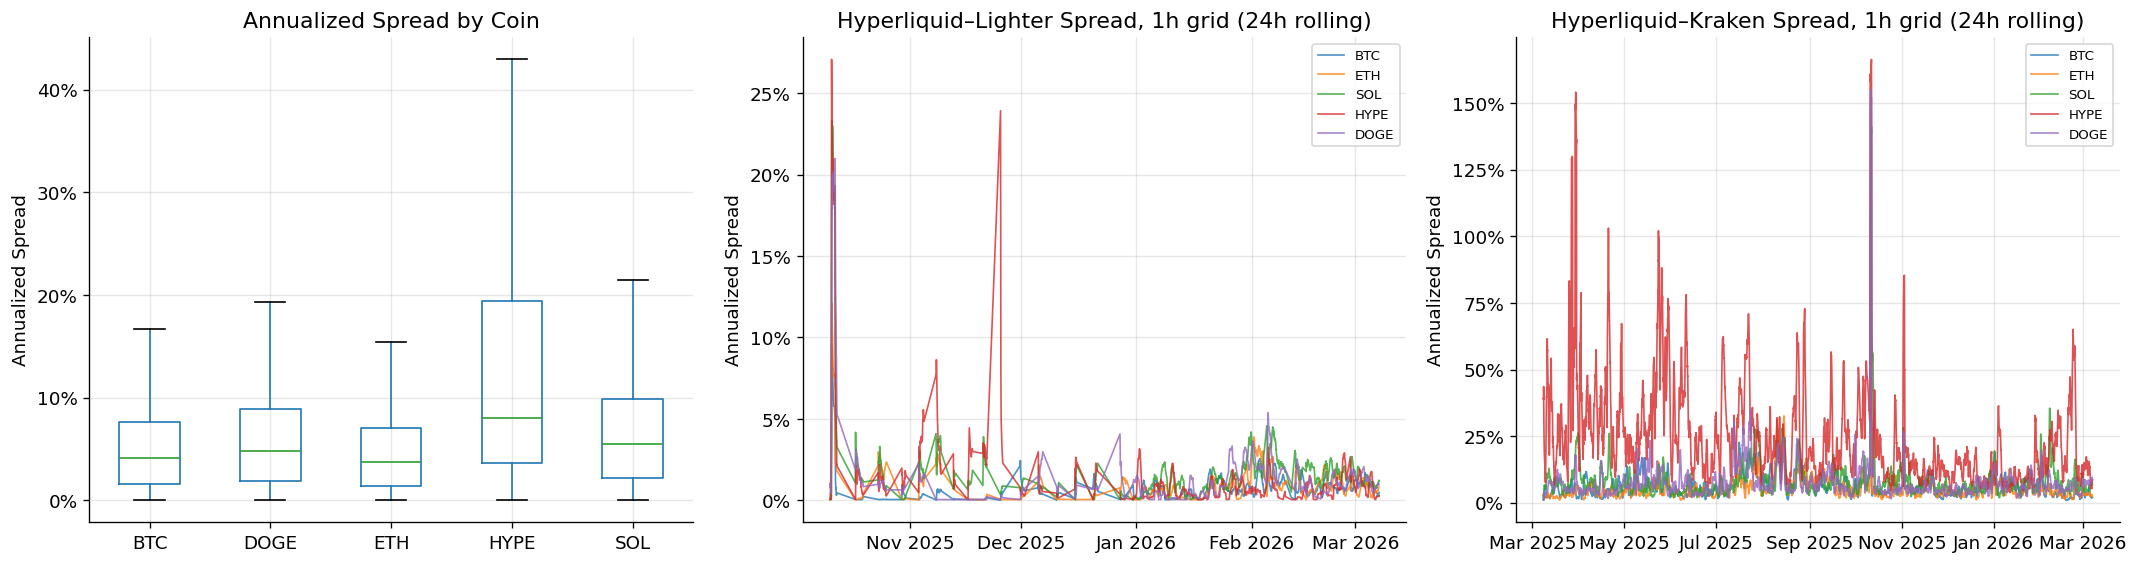

In [22]:
# Spread distributions and time series
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: spread distribution by coin
spreads.boxplot(column="spread_ann", by="coin", ax=axes[0], showfliers=False)
axes[0].set_title("Annualized Spread by Coin")
axes[0].set_ylabel("Annualized Spread")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.sca(axes[0])
plt.xticks(rotation=0)

# Middle: Hyperliquid–Lighter spread, 1h grid (24h rolling)
for coin in coins:
    pair = spreads[
        (spreads["coin"] == coin)
        & (spreads["grid"] == "1h")
        & (
            ((spreads["long_venue"] == "hyperliquid") & (spreads["short_venue"] == "lighter"))
            | ((spreads["long_venue"] == "lighter") & (spreads["short_venue"] == "hyperliquid"))
        )
    ]
    if pair.empty:
        continue
    pair = pair.sort_values("timestamp").set_index("timestamp")
    rolling = pair["spread_ann"].rolling("24h").mean()
    axes[1].plot(rolling.index, rolling.values, label=coin, alpha=0.8, linewidth=1)

axes[1].set_title("Hyperliquid–Lighter Spread, 1h grid (24h rolling)")
axes[1].set_ylabel("Annualized Spread")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Right: Hyperliquid–Kraken spread, 1h grid (24h rolling)
for coin in coins:
    pair = spreads[
        (spreads["coin"] == coin)
        & (spreads["grid"] == "1h")
        & (
            ((spreads["long_venue"] == "hyperliquid") & (spreads["short_venue"] == "kraken"))
            | ((spreads["long_venue"] == "kraken") & (spreads["short_venue"] == "hyperliquid"))
        )
    ]
    if pair.empty:
        continue
    pair = pair.sort_values("timestamp").set_index("timestamp")
    rolling = pair["spread_ann"].rolling("24h").mean()
    axes[2].plot(rolling.index, rolling.values, label=coin, alpha=0.8, linewidth=1)

axes[2].set_title("Hyperliquid–Kraken Spread, 1h grid (24h rolling)")
axes[2].set_ylabel("Annualized Spread")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("")
plt.tight_layout()
plt.show()

/var/folders/tz/w6ww66wn20b65n4pwvqrrjh40000gn/T/ipykernel_69384/3730846176.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


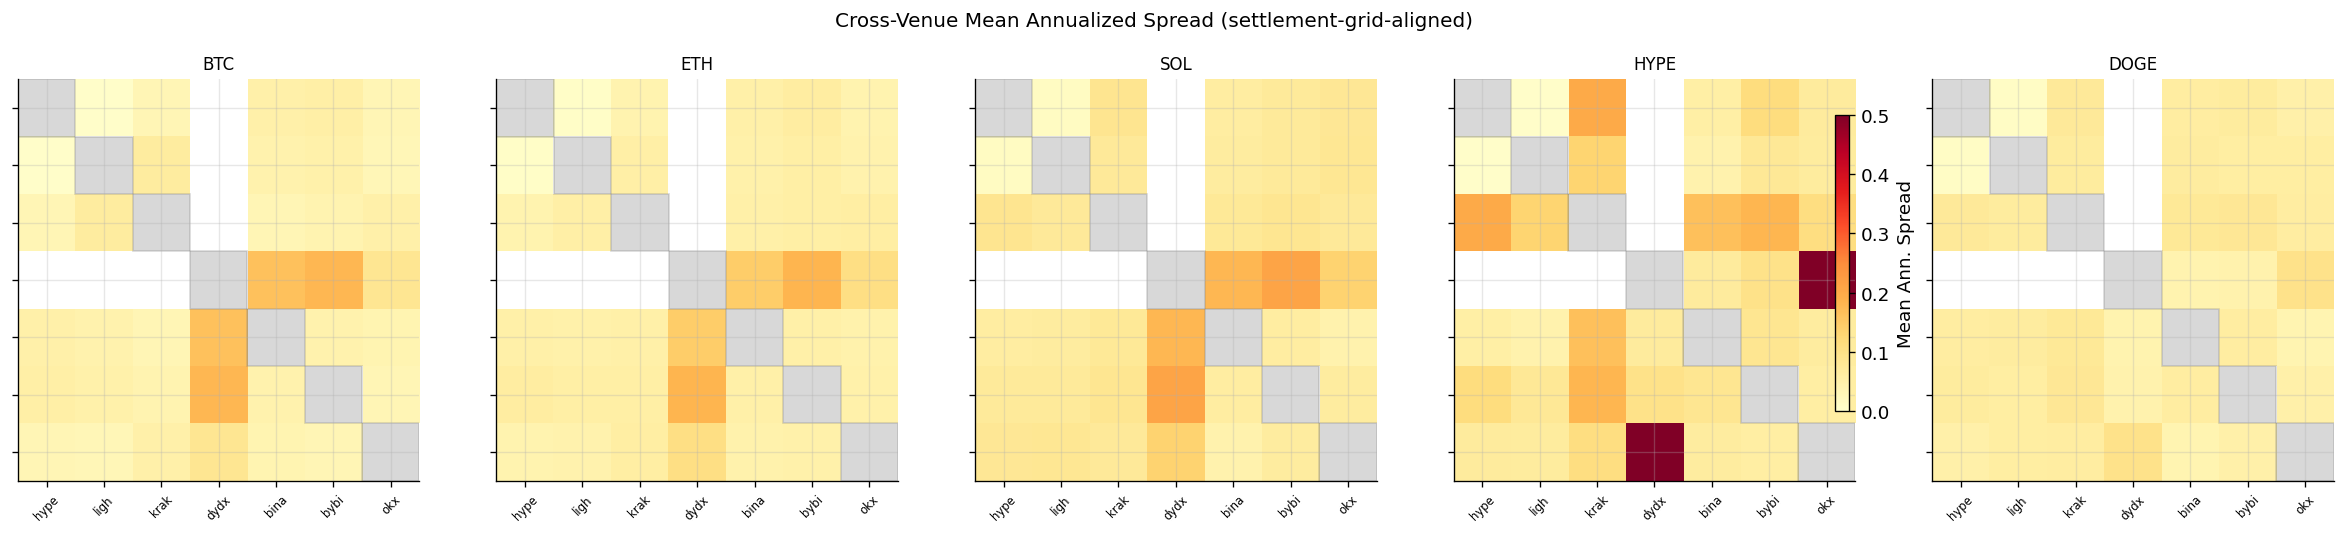

In [23]:
# Mean annualized spread heatmap: venue × venue per coin (all venues, settlement-grid-aligned)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
venue_order = ["hyperliquid", "lighter", "kraken", "dydx", "binance", "bybit", "okx"]

for ax, coin in zip(axes, coins):
    matrix = pd.DataFrame(np.nan, index=venue_order, columns=venue_order)
    coin_spreads = spreads[spreads["coin"] == coin]
    for (lv, sv), val in (
        coin_spreads.groupby(["long_venue", "short_venue"])["spread_ann"].mean().items()
    ):
        if lv in venue_order and sv in venue_order:
            matrix.loc[lv, sv] = val
            matrix.loc[sv, lv] = val

    im = ax.imshow(matrix.values, cmap="YlOrRd", vmin=0, vmax=0.50)
    ax.set_xticks(range(len(venue_order)))
    ax.set_xticklabels([v[:4] for v in venue_order], fontsize=7, rotation=45)
    ax.set_yticks(range(len(venue_order)))
    ax.set_yticklabels([v[:4] for v in venue_order] if ax == axes[0] else [], fontsize=7)
    ax.set_title(coin, fontsize=10)
    # Diagonal
    for k in range(len(venue_order)):
        ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1, fill=True, color="gray", alpha=0.3))

fig.colorbar(im, ax=axes, shrink=0.8, label="Mean Ann. Spread")
fig.suptitle("Cross-Venue Mean Annualized Spread (settlement-grid-aligned)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Spread EDA Takeaways

**Settlement-grid alignment matters.** Venues that settle hourly (Hyperliquid, Lighter, Kraken, dYdX) can be compared on a 1h grid. Venues that settle every 8h (Binance, Bybit, OKX) can only be meaningfully compared at 8h intervals. For mixed pairs, we aggregate the hourly leg to 8h before computing spreads — this avoids overstating opportunities at hours where the 8h leg hasn't actually settled.

**Kraken is the most frequent spread counterparty.** The Hyperliquid–Kraken pair provides the richest hourly data (8,700+ observations per coin) with mean annualized spreads of 5–25%. Lighter pairs show structurally wider spreads due to its higher base interest rate component, representing real cash flows but with thinner orderbooks.

**Spreads are mean-reverting with periodic spikes.** The rolling time series shows spreads fluctuating around a positive baseline with spikes during volatility events — exactly the pattern the carry strategy's entry/exit thresholds exploit.

**Token ranking by spread opportunity:** HYPE >> SOL ≈ DOGE > ETH ≈ BTC.

In [24]:
# Grid search: pooled per-coin to avoid overfitting to pair-specific noise
# Each (entry, exit, max_hold) is evaluated across ALL venue pairs for a coin,
# and the pooled Sharpe is computed from the combined trade PnL distribution.
# PnL is net of taker fees (deducted per round-trip in evaluate_carry).
from funding_the_fall.strategy.carry import (
    CarryParams,
    simulate_carry,
    evaluate_carry,
    grid_search_per_coin,
    PooledCarryParams,
)
from funding_the_fall.backtest.costs import VENUE_FEES

# Rename spread_ann → spread_annualized for compatibility with carry module
carry_spreads = spreads.rename(columns={"spread_ann": "spread_annualized"}).copy()

# Pooled grid search per coin
best_per_coin: dict[str, PooledCarryParams] = {}
for coin in coins:
    results = grid_search_per_coin(carry_spreads, coin, min_trades=3, progress=True)
    if results:
        best = results[0]
        best_per_coin[coin] = best.params
        print(
            f"  {coin:5s}  entry≥{best.params.entry_spread:.0%}  "
            f"exit≤{best.params.exit_spread:.0%}  "
            f"max_hold={best.params.max_holding_epochs:2d}ep  "
            f"trades={best.total_trades:3d}  "
            f"pooled_Sharpe={best.pooled_sharpe:.2f}  "
            f"win={best.avg_win_rate:.0%}"
        )

# Apply best per-coin params to all venue pairs and generate signals
pairs = carry_spreads[["coin", "long_venue", "short_venue"]].drop_duplicates().values.tolist()
all_carry_signals = []
pair_results: dict[tuple, float] = {}  # for display
for coin_name, lv, sv in pairs:
    if coin_name not in best_per_coin:
        continue
    bp = best_per_coin[coin_name]
    p = CarryParams(
        coin=coin_name,
        long_venue=lv,
        short_venue=sv,
        entry_spread=bp.entry_spread,
        exit_spread=bp.exit_spread,
        max_holding_epochs=bp.max_holding_epochs,
    )
    sigs = simulate_carry(carry_spreads, p)
    r = evaluate_carry(carry_spreads, p)
    if r.n_trades > 0:
        all_carry_signals.extend(sigs)
        pair_results[(coin_name, lv, sv)] = r.sharpe

print(
    f"\nTotal carry signals generated: {len(all_carry_signals)} "
    f"({sum(1 for s in all_carry_signals if s.action == 'enter')} entries, "
    f"{len(pair_results)} active pairs)"
)

  BTC    entry≥35%  exit≤1%  max_hold=45ep  trades= 12  pooled_Sharpe=1.27  win=33%
  ETH    entry≥35%  exit≤1%  max_hold=60ep  trades= 25  pooled_Sharpe=0.98  win=32%
  SOL    entry≥35%  exit≤1%  max_hold=60ep  trades= 69  pooled_Sharpe=2.52  win=48%
  HYPE   entry≥35%  exit≤1%  max_hold=60ep  trades=225  pooled_Sharpe=1.88  win=56%
  DOGE   entry≥35%  exit≤1%  max_hold=60ep  trades= 37  pooled_Sharpe=0.41  win=27%

Total carry signals generated: 736 (368 entries, 95 active pairs)


---
## 6. Position Allocation

The allocation module combines carry signals and cascade risk into **margin-based** position targets. Budgets are denominated in collateral (margin), not notional — notional = collateral $\times$ leverage. This ensures total posted margin never exceeds NAV.

**Leverage by strategy leg:**
| Leg | Leverage | Rationale |
|-----|----------|-----------|
| Carry (each leg of delta-neutral pair) | 4x | Low net exposure; risk is spread mean-reversion, not price |
| Cascade short | 1.5x | Directional; adverse move = full notional loss at leverage |

**Budget allocation:**
- **85% NAV** baseline margin to carry, scaled down by up to 30% when cascade risk is elevated
- **Up to 15% NAV** margin to cascade opportunistic shorts, scaled up with `risk_score`
- **Remainder held as cash** — dry powder and risk buffer

**Risk limits:** max 5x gross leverage, 40% single-exchange concentration, 10% net delta.

Each carry trade posts isolated margin on two venues (long leg + short leg). If one leg is liquidated (equity < 0.5% of notional), the other is force-closed to avoid a naked directional position.

In [25]:
# Allocate positions using carry signals + cascade risk (margin-based)
from funding_the_fall.strategy.allocation import (
    allocate_positions,
    CARRY_BASE_WEIGHT,
    CASCADE_MAX_WEIGHT,
    CARRY_RISK_DAMPING,
)

NAV = 1_000_000  # $1M portfolio
CARRY_LEV = 4.0
CASCADE_LEV = 1.5

# Get latest aggregate cascade signal (venue-matched)
latest_snap = oi_matched.filter(pl.col("timestamp") == oi_matched["timestamp"].max())
latest_positions = build_positions_tiered(latest_snap)
agg_signal = cascade_risk_signal(
    latest_positions, current_price=1.0, orderbook_depth_usd=total_depth
)

# Only pass entry signals (most recent batch) to allocator
entry_signals = [s for s in all_carry_signals if s.action == "enter"]

targets = allocate_positions(
    carry_signals=entry_signals,
    cascade_signal=agg_signal,
    nav=NAV,
    per_coin_signals=signals,
    deepest_venue="binance",
    carry_leverage=CARRY_LEV,
    cascade_leverage=CASCADE_LEV,
)

# Summarize allocation
carry_notional = sum(t.notional_usd for t in targets if t.strategy == "carry")
carry_margin = sum(t.collateral_usd for t in targets if t.strategy == "carry")
cascade_notional = sum(t.notional_usd for t in targets if t.strategy == "cascade")
cascade_margin = sum(t.collateral_usd for t in targets if t.strategy == "cascade")
gross = sum(t.notional_usd for t in targets)
total_margin = sum(t.collateral_usd for t in targets)
net = sum(t.notional_usd * (1 if t.side == "long" else -1) for t in targets)

risk_score = agg_signal["risk_score"]
carry_scale = 1.0 - CARRY_RISK_DAMPING * risk_score

print(
    f"Aggregate cascade risk_score: {risk_score:.3f}  →  carry scaled to {carry_scale:.0%} of baseline"
)
print(f"\n{'Strategy':<12} {'Margin':>12} {'Notional':>12} {'Leverage':>9} {'% NAV':>8}")
print("-" * 55)
print(
    f"{'Carry':<12} ${carry_margin:>11,.0f} ${carry_notional:>11,.0f} {CARRY_LEV:>8.1f}x {carry_notional / NAV:>7.1%}"
)
print(
    f"{'Cascade':<12} ${cascade_margin:>11,.0f} ${cascade_notional:>11,.0f} {CASCADE_LEV:>8.1f}x {cascade_notional / NAV:>7.1%}"
)
print(
    f"{'Cash':<12} ${NAV - total_margin:>11,.0f} {'':>12} {'':>9} {(NAV - total_margin) / NAV:>7.1%}"
)
print("-" * 55)
print(f"{'Gross':12} ${total_margin:>11,.0f} ${gross:>11,.0f} {gross / NAV:>8.1f}x")
print(f"{'Net delta':12} {'':>12} ${net:>11,.0f} {'':>9} {net / NAV:>7.1%}")
print(f"\nTotal position targets: {len(targets)}")

Aggregate cascade risk_score: 0.974  →  carry scaled to 71% of baseline

Strategy           Margin     Notional  Leverage    % NAV
-------------------------------------------------------
Carry        $    289,020 $  1,156,078      4.0x  115.6%
Cascade      $     69,914 $    104,871      1.5x   10.5%
Cash         $    641,067                          64.1%
-------------------------------------------------------
Gross        $    358,933 $  1,260,949      1.3x
Net delta                 $   -100,000            -10.0%

Total position targets: 738


In [26]:
# Risk limits and allocation breakdown by venue/coin
venue_exp = {}
coin_exp = {}
for t in targets:
    venue_exp[t.venue] = venue_exp.get(t.venue, 0) + t.notional_usd
    coin_exp[t.coin] = coin_exp.get(t.coin, 0) + t.notional_usd

print("Exposure by venue (notional):")
for v, e in sorted(venue_exp.items(), key=lambda x: -x[1]):
    print(f"  {v:14s} ${e:>11,.0f}  ({e / NAV:.1%} of NAV)")

print(f"\nExposure by coin (notional):")
for c, e in sorted(coin_exp.items(), key=lambda x: -x[1]):
    print(f"  {c:5s} ${e:>11,.0f}  ({e / NAV:.1%} of NAV)")

# Show cascade leg detail
cascade_targets = [t for t in targets if t.strategy == "cascade"]
if cascade_targets:
    print(f"\nCascade shorts (weighted by per-coin amplification, {CASCADE_LEV:.1f}x leverage):")
    for t in sorted(cascade_targets, key=lambda x: -x.notional_usd):
        amp = signals.get(t.coin, {}).get("amplification_at_5pct", 0)
        print(
            f"  SHORT {t.coin:5s} on {t.venue:12s}  "
            f"margin=${t.collateral_usd:>9,.0f}  notional=${t.notional_usd:>10,.0f}  (A(5%)={amp:.1f}x)"
        )

# Risk limit check
print(f"\n--- Risk Limit Check ---")
print(
    f"  Gross leverage:  {gross / NAV:.2f}x  (limit: 5.0x)  {'PASS' if gross / NAV <= 5.0 else 'FAIL'}"
)
max_venue_pct = max(venue_exp.values()) / NAV if venue_exp else 0
print(
    f"  Max venue:       {max_venue_pct:.1%}  (limit: 40%)   {'PASS' if max_venue_pct <= 0.40 else 'FAIL'}"
)
print(
    f"  Net delta:       {abs(net) / NAV:.1%}  (limit: 10%)   {'PASS' if abs(net) / NAV <= 0.10 else 'FAIL'}"
)
print(
    f"  Total margin:    {total_margin / NAV:.1%} of NAV       {'PASS' if total_margin <= NAV else 'FAIL'}"
)

Exposure by venue (notional):
  kraken         $    398,690  (39.9% of NAV)
  hyperliquid    $    267,089  (26.7% of NAV)
  binance        $    228,351  (22.8% of NAV)
  lighter        $    147,356  (14.7% of NAV)
  bybit          $    143,315  (14.3% of NAV)
  dydx           $     50,533  (5.1% of NAV)
  okx            $     25,614  (2.6% of NAV)

Exposure by coin (notional):
  HYPE  $    568,622  (56.9% of NAV)
  DOGE  $    292,710  (29.3% of NAV)
  SOL   $    250,890  (25.1% of NAV)
  ETH   $     75,649  (7.6% of NAV)
  BTC   $     73,079  (7.3% of NAV)

Cascade shorts (weighted by per-coin amplification, 1.5x leverage):
  SHORT HYPE  on binance       margin=$   38,590  notional=$    57,885  (A(5%)=20.0x)
  SHORT BTC   on binance       margin=$   31,324  notional=$    46,986  (A(5%)=20.0x)

--- Risk Limit Check ---
  Gross leverage:  1.26x  (limit: 5.0x)  PASS
  Max venue:       39.9%  (limit: 40%)   PASS
  Net delta:       10.0%  (limit: 10%)   PASS
  Total margin:    35.9% of NAV 

---
## 7. Backtest

The backtest engine processes funding epochs sequentially with position-level isolated margin:
1. Apply funding payments to open positions
2. Check liquidations (if one carry leg is liquidated, force-close its pair)
3. Process pre-computed carry and cascade signals (open/close positions)
4. Record portfolio state (NAV, leverage, funding, costs)

Carry trades open two legs (long + short) at 4x leverage each. Cascade shorts open a single position at 1.5x. Taker fees are applied at entry and exit per `VENUE_FEES`.

In [27]:
# Pre-compute cascade signals from OI time series
from funding_the_fall.models.cascade import generate_cascade_signals, CascadeSignal
from funding_the_fall.backtest.engine import run_backtest
from funding_the_fall.backtest.performance import (
    compute_performance_from_result,
    pnl_decomposition,
)

cascade_signals = generate_cascade_signals(
    oi_df=oi_matched,
    depth_per_coin=measured_depth,
    venue="hyperliquid",
    top_n=2,
    rebalance_hours=24,
    risk_threshold=0.5,
)

n_enter = sum(1 for s in cascade_signals if s.action == "enter")
n_exit = sum(1 for s in cascade_signals if s.action == "exit")
coins_targeted = set(s.coin for s in cascade_signals if s.action == "enter")
print(f"Cascade signals: {n_enter} entries, {n_exit} exits")
print(f"Coins targeted: {sorted(coins_targeted)}")

Cascade signals: 4 entries, 4 exits
Coins targeted: ['BTC', 'HYPE']


In [28]:
# Run backtest with carry + cascade signals
funding_pd = funding.to_pandas()
candles_pd = candles.to_pandas()

result = run_backtest(
    carry_signals=all_carry_signals,
    funding_df=funding_pd,
    candles_df=candles_pd,
    initial_nav=1_000_000.0,
    carry_leverage=CARRY_LEV,
    carry_budget_pct=0.85,
    cascade_signals=cascade_signals,
    cascade_leverage=CASCADE_LEV,
    cascade_budget_pct=0.15,
)

nav = result.nav_series()
trades = result.trades_df()
print(f"Backtest: {len(result.portfolio_states)} epochs, {result.trade_count} trades")
print(f"NAV: ${nav.iloc[0]:,.0f} → ${nav.iloc[-1]:,.0f} ({nav.iloc[-1] / nav.iloc[0] - 1:+.2%})")
print(f"Carry trades: {len(trades[trades['strategy'] == 'carry']) if not trades.empty else 0}")
print(f"Cascade trades: {len(trades[trades['strategy'] == 'cascade']) if not trades.empty else 0}")
if not trades.empty and "strategy" in trades.columns:
    liq = trades[trades["strategy"].str.contains("liquidation")]
    print(f"Liquidations: {len(liq)}")

Backtest: 8737 epochs, 635 trades
NAV: $1,000,000 → $165,282 (-83.47%)
Carry trades: 628
Cascade trades: 3
Liquidations: 4


In [29]:
# Zero-cost backtest (no transaction fees) for comparison
result_zero = run_backtest(
    carry_signals=all_carry_signals,
    funding_df=funding_pd,
    candles_df=candles_pd,
    initial_nav=1_000_000.0,
    carry_leverage=CARRY_LEV,
    carry_budget_pct=0.85,
    cascade_signals=cascade_signals,
    cascade_leverage=CASCADE_LEV,
    cascade_budget_pct=0.15,
    fee_multiplier=0.0,
)

nav_zero = result_zero.nav_series()
stats_zero = compute_performance_from_result(result_zero, risk_free_rate=0.03)
stats = compute_performance_from_result(result, risk_free_rate=0.03)

print(f"{'Metric':<25} {'With Fees':>14} {'Zero Fees':>14} {'Fee Drag':>14}")
print("-" * 70)
for label, v_real, v_zero in [
    ("Total Return", stats.total_return, stats_zero.total_return),
    ("Ann. Return", stats.annualized_return, stats_zero.annualized_return),
    ("Sharpe", stats.sharpe_ratio, stats_zero.sharpe_ratio),
    ("Max Drawdown", stats.max_drawdown, stats_zero.max_drawdown),
]:
    if "Sharpe" in label:
        print(f"{label:<25} {v_real:>14.2f} {v_zero:>14.2f} {v_real - v_zero:>+14.2f}")
    else:
        print(f"{label:<25} {v_real:>14.2%} {v_zero:>14.2%} {v_real - v_zero:>+14.2%}")
print(
    f"{'Trading Costs':<25} ${stats.total_trading_costs:>13,.0f} ${stats_zero.total_trading_costs:>13,.0f}"
)

Metric                         With Fees      Zero Fees       Fee Drag
----------------------------------------------------------------------
Total Return                     -83.47%        -77.51%         -5.96%
Ann. Return                      -83.55%        -77.60%         -5.95%
Sharpe                             -0.73          -0.69          -0.05
Max Drawdown                     -87.62%        -84.43%         -3.19%
Trading Costs             $      833,537 $      763,535


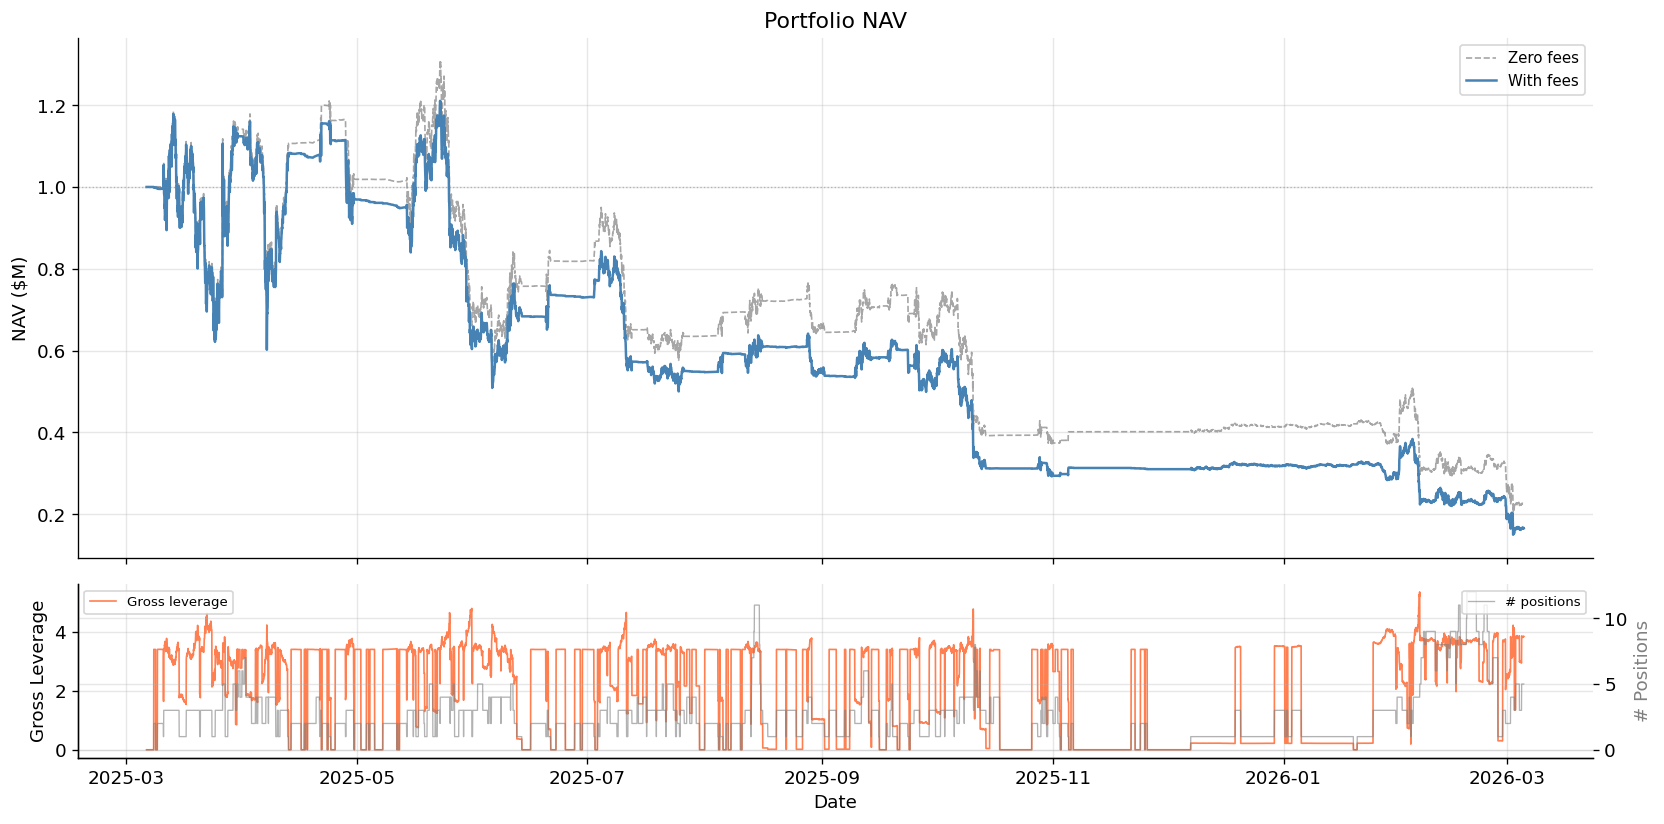

In [30]:
# NAV curve comparison and leverage over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# NAV: with fees vs zero fees
ax = axes[0]
ax.plot(
    nav_zero.index, nav_zero.values / 1e6, color="gray", lw=1, ls="--", alpha=0.7, label="Zero fees"
)
ax.plot(nav.index, nav.values / 1e6, color="steelblue", lw=1.5, label="With fees")
ax.axhline(1.0, color="gray", ls=":", lw=0.8, alpha=0.5)
ax.set_ylabel("NAV ($M)")
ax.set_title("Portfolio NAV")
ax.legend(fontsize=9)

# Leverage + positions
states_df = pd.DataFrame([s.__dict__ for s in result.portfolio_states])
ax2 = axes[1]
ax2.plot(
    states_df["timestamp"], states_df["gross_leverage"], color="coral", lw=1, label="Gross leverage"
)
ax2.set_ylabel("Gross Leverage")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8, loc="upper left")

ax3 = ax2.twinx()
ax3.plot(
    states_df["timestamp"],
    states_df["n_positions"],
    color="gray",
    lw=0.8,
    alpha=0.6,
    label="# positions",
)
ax3.set_ylabel("# Positions", color="gray")
ax3.legend(fontsize=8, loc="upper right")

fig.tight_layout()
plt.show()

In [31]:
# Performance statistics
stats = compute_performance_from_result(result, risk_free_rate=0.05)

perf_rows = [
    ("Total Return", f"{stats.total_return:+.2%}"),
    ("Annualized Return", f"{stats.annualized_return:+.2%}"),
    ("Annualized Volatility", f"{stats.annualized_vol:.2%}"),
    ("Sharpe Ratio", f"{stats.sharpe_ratio:.2f}"),
    ("Calmar Ratio", f"{stats.calmar_ratio:.2f}"),
    ("Max Drawdown", f"{stats.max_drawdown:.2%}"),
    ("Max DD Duration", f"{stats.max_drawdown_duration_days:.0f} days"),
    ("Total Trades", f"{stats.total_trades:,}"),
    ("Cumulative Funding", f"${stats.total_funding_collected:+,.0f}"),
    ("Cumulative Trading Costs", f"${stats.total_trading_costs:,.0f}"),
    ("Net PnL", f"${stats.net_pnl:+,.0f}"),
]
perf_table = pd.DataFrame(perf_rows, columns=["Metric", "Value"])
print(perf_table.to_string(index=False))

                  Metric     Value
            Total Return   -83.47%
       Annualized Return   -83.55%
   Annualized Volatility   117.78%
            Sharpe Ratio     -0.75
            Calmar Ratio     -0.95
            Max Drawdown   -87.62%
         Max DD Duration  286 days
            Total Trades       635
      Cumulative Funding  $+57,249
Cumulative Trading Costs  $833,537
                 Net PnL $-834,718


---
## 8. Performance Analysis

Drawdown analysis, rolling Sharpe, trade-level statistics, and PnL attribution across carry and cascade legs.

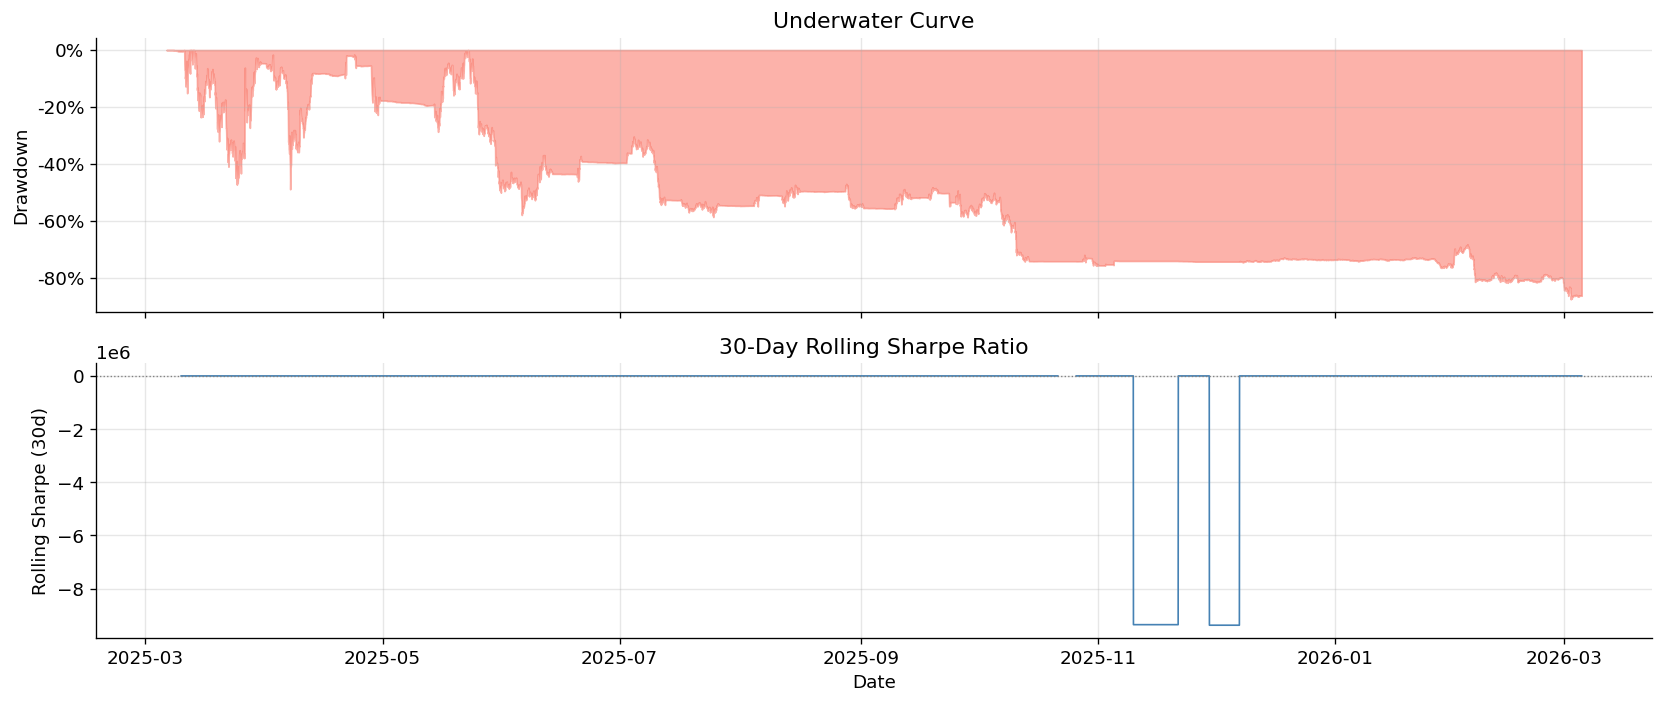

In [32]:
# Drawdown + rolling Sharpe
returns = nav.pct_change().dropna()
cummax = nav.cummax()
drawdown = (nav - cummax) / cummax

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

# Underwater plot
ax = axes[0]
ax.fill_between(drawdown.index, drawdown.values, 0, color="salmon", alpha=0.6)
ax.set_ylabel("Drawdown")
ax.set_title("Underwater Curve")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Rolling Sharpe (30-day = ~90 8h epochs)
window = 90
if len(returns) > window:
    rolling_mean = returns.rolling(window).mean()
    rolling_std = returns.rolling(window).std()
    # Annualize: 3 epochs/day × 365
    rolling_sharpe = (rolling_mean * 3 * 365 - 0.05) / (rolling_std * np.sqrt(3 * 365))
    ax2 = axes[1]
    ax2.plot(rolling_sharpe.index, rolling_sharpe.values, color="steelblue", lw=1)
    ax2.axhline(0, color="gray", ls=":", lw=0.8)
    ax2.set_ylabel("Rolling Sharpe (30d)")
    ax2.set_xlabel("Date")
    ax2.set_title("30-Day Rolling Sharpe Ratio")

fig.tight_layout()
plt.show()

In [33]:
# Trade statistics by strategy
if not trades.empty:
    for strat in ["carry", "cascade"]:
        st = trades[trades["strategy"] == strat]
        if st.empty:
            continue
        coins_traded = st["coin"].nunique()
        total_notional = st["notional_usd"].sum()
        total_fees = st["fee_usd"].sum()
        print(f"--- {strat.upper()} ---")
        print(f"  Trades: {len(st)}")
        print(f"  Coins: {sorted(st['coin'].unique())}")
        print(f"  Total notional: ${total_notional:,.0f}")
        print(f"  Total fees: ${total_fees:,.0f}")
        print(f"  Avg fee/trade: ${total_fees / len(st):,.2f}")
        print()

    # Liquidation summary
    liq_trades = trades[trades["strategy"].str.contains("liquidation")]
    if not liq_trades.empty:
        print(f"--- LIQUIDATIONS ---")
        print(f"  Total: {len(liq_trades)}")
        for coin in sorted(liq_trades["coin"].unique()):
            n = len(liq_trades[liq_trades["coin"] == coin])
            print(f"  {coin}: {n}")
    else:
        print("No liquidations.")
else:
    print("No trades executed.")

--- CARRY ---
  Trades: 628
  Coins: ['BTC', 'DOGE', 'ETH', 'HYPE', 'SOL']
  Total notional: $390,489,625
  Total fees: $187,868
  Avg fee/trade: $299.15

--- CASCADE ---
  Trades: 3
  Coins: ['HYPE']
  Total notional: $211,903
  Total fees: $95
  Avg fee/trade: $31.79

--- LIQUIDATIONS ---
  Total: 4
  HYPE: 3
  SOL: 1


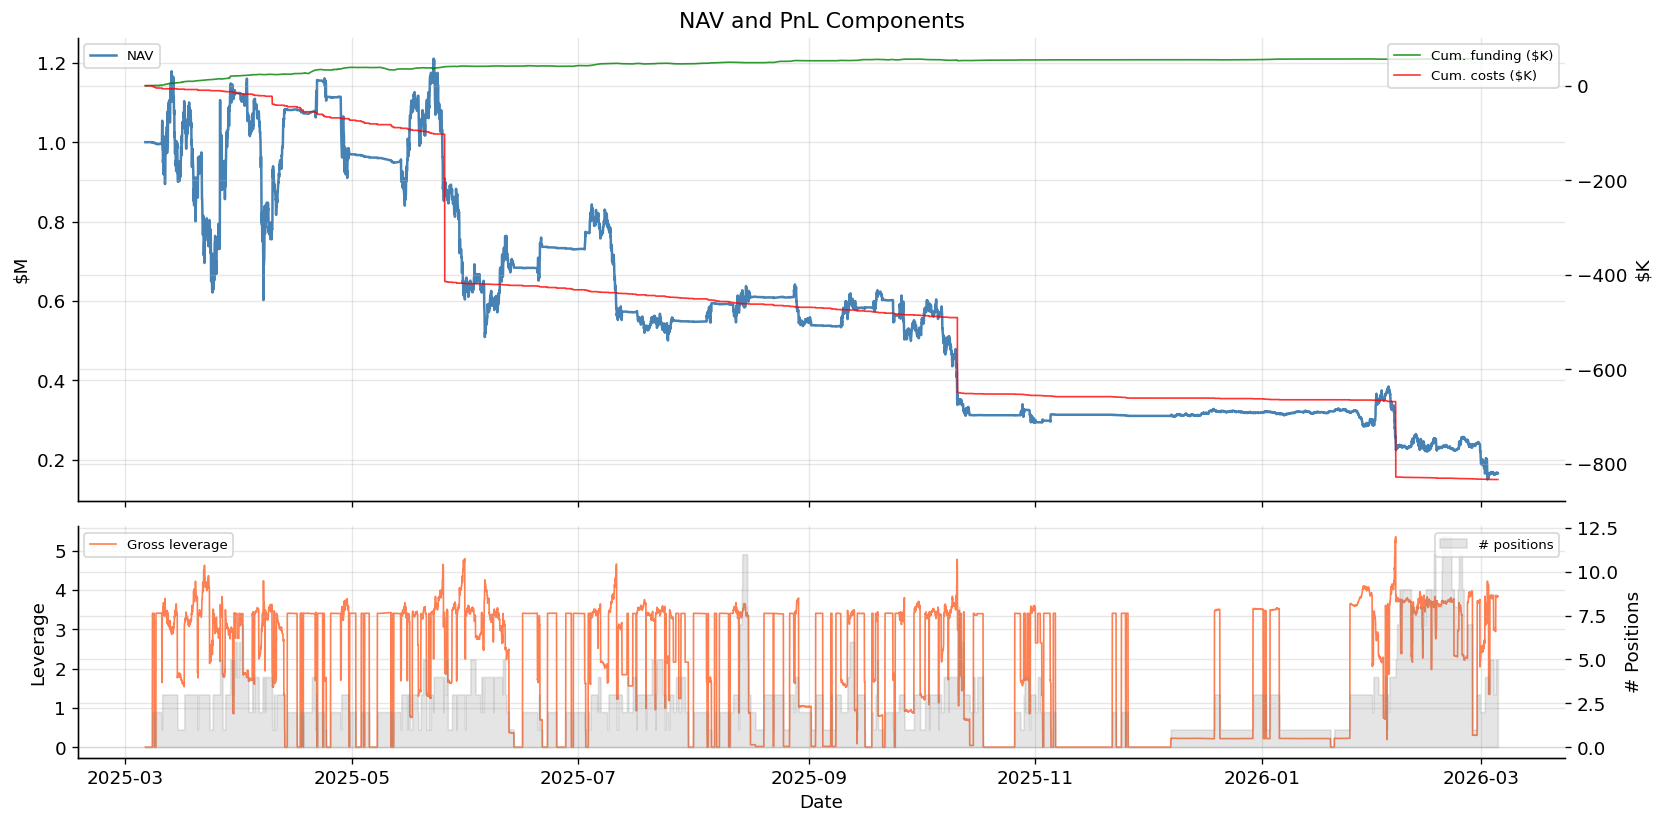

Initial NAV:    $   1,000,000
Final NAV:      $     165,282
Net PnL:        $    -834,718
Cum. Funding:   $     +57,249
Cum. Costs:     $     833,537
Price PnL:      $     -58,429


In [34]:
# PnL decomposition: NAV, cumulative funding, cumulative costs
decomp = pnl_decomposition(result)

if not decomp.empty:
    fig, axes = plt.subplots(
        2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )

    # NAV + cumulative funding
    ax = axes[0]
    ax.plot(decomp.index, decomp["nav"] / 1e6, color="steelblue", lw=1.5, label="NAV")
    ax.set_ylabel("$M")
    ax.set_title("NAV and PnL Components")
    ax.legend(fontsize=8, loc="upper left")

    ax_r = ax.twinx()
    ax_r.plot(
        decomp.index,
        decomp["cumulative_funding"] / 1e3,
        color="green",
        lw=1,
        alpha=0.8,
        label="Cum. funding ($K)",
    )
    ax_r.plot(
        decomp.index,
        -decomp["cumulative_costs"] / 1e3,
        color="red",
        lw=1,
        alpha=0.8,
        label="Cum. costs ($K)",
    )
    ax_r.set_ylabel("$K")
    ax_r.legend(fontsize=8, loc="upper right")

    # Gross leverage + position count
    ax2 = axes[1]
    ax2.plot(decomp.index, decomp["gross_leverage"], color="coral", lw=1, label="Gross leverage")
    ax2.set_ylabel("Leverage")
    ax2.set_xlabel("Date")
    ax2.legend(fontsize=8, loc="upper left")

    ax3 = ax2.twinx()
    ax3.fill_between(
        decomp.index, decomp["n_positions"], 0, color="gray", alpha=0.2, label="# positions"
    )
    ax3.set_ylabel("# Positions")
    ax3.legend(fontsize=8, loc="upper right")

    fig.tight_layout()
    plt.show()

    # Final decomposition summary
    final = decomp.iloc[-1]
    initial_nav = decomp["nav"].iloc[0]
    print(f"Initial NAV:    ${initial_nav:>12,.0f}")
    print(f"Final NAV:      ${final['nav']:>12,.0f}")
    print(f"Net PnL:        ${final['nav'] - initial_nav:>+12,.0f}")
    print(f"Cum. Funding:   ${final['cumulative_funding']:>+12,.0f}")
    print(f"Cum. Costs:     ${final['cumulative_costs']:>12,.0f}")
    print(
        f"Price PnL:      ${final['nav'] - initial_nav - final['cumulative_funding'] + final['cumulative_costs']:>+12,.0f}"
    )
else:
    print("No portfolio states to decompose.")

---
## 9. Conclusion

We presented **Funding the Fall**, a two-component crypto perpetual futures strategy.
The backtest over 12 months (Mar 2025–Mar 2026) on a $1M portfolio produced a total
return of **-83.5%**, Sharpe of **-0.73**, and max drawdown of **-87.6%**. The strategy
failed to be profitable, and the decomposition of PnL reveals why.

**What worked:**
- **Funding income was positive (+$61K).** The carry signal correctly identified
  cross-venue spreads, and delta-neutral pairs collected net funding over time. This
  confirms the economic premise: funding rate dispersion across venues creates real
  arbitrage-like opportunities.
- **Cascade risk identification was sound.** OI/depth ratios for HYPE (1048x) and BTC
  (329x) correctly flagged fragile markets. The cascade model's binary amplification
  structure — cascades are step functions at crypto leverage ratios — is a genuine
  feature of the microstructure, not a modeling artifact.
- **The allocation overlay behaved as designed.** Carry exposure scaled down during
  high-risk periods, and cascade shorts targeted the correct coins (HYPE, BTC).

**What failed:**
- **Trading costs dominated.** $829K in taker fees against $61K in funding income.
  At 4x leverage, each carry pair's entry/exit generates notional turnover of 8x the
  margin posted. With 5bps taker fees per leg, the round-trip cost per trade is ~40bps
  of margin. The grid search selected entry thresholds of 35% annualized spread, but
  with 628 carry trades over 8,737 epochs, the average holding period was too short for
  funding to accumulate enough to cover entry/exit costs.
- **Leverage amplified the bleed.** 4x leverage on each carry leg means every
  basis point of fee is magnified 4x relative to margin. A 5bps taker fee becomes
  20bps of collateral per leg per trade — 80bps round-trip for the pair. This
  mechanical cost exceeds the per-epoch funding spread for most pairs.
- **Cascade leg was underutilized.** Only 3 cascade trades executed (4 signals total),
  contributing negligibly to returns. The 24-hour rebalance interval and 0.5 risk
  threshold were conservative, and the 15% budget cap limited notional exposure.

**Lessons and extensions:**
- **Cost-aware entry thresholds.** The grid search optimized Sharpe on per-epoch PnL
  net of fees, but did not penalize turnover directly. A cost-aware objective —
  e.g., maximizing $\sum(\text{funding}) - \sum(\text{fees})$ rather than Sharpe —
  would favor longer holding periods and fewer trades.
- **Lower leverage or maker execution.** Reducing carry leverage to 2x halves the
  notional turnover per dollar of margin. Alternatively, maker orders (0bps on
  Hyperliquid and Lighter) would eliminate the dominant cost, though execution risk
  and latency become concerns.
- **Wider entry, narrower exit.** Requiring spreads above 50%+ annualized before entry
  and tolerating smaller spreads before exit would concentrate on the highest-conviction
  opportunities and extend holding periods.
- **Deeper cascade integration.** The cascade leg's 4 signals over 12 months suggests
  the threshold and rebalance parameters were too conservative. Lowering
  `risk_threshold` or shortening `rebalance_hours` could generate more opportunistic
  short exposure, though this introduces directional risk.

The core economic thesis — that cross-venue funding dispersion and OI-driven cascade
fragility create exploitable opportunities — is supported by the data. Funding spreads
are real and persistent (HYPE pairs averaged 58-61% annualized), and cascade amplification
is structurally embedded in the perp microstructure. The failure is one of implementation,
not premise: a production version of this strategy would need to solve the execution cost
problem, likely through maker-only order routing and much longer holding periods.

## References

1. **Almgren, R. & Chriss, N.** (2001). Optimal execution of portfolio transactions. *Journal of Risk*, 3, 5-39.
2. **Kou, S.G.** (2002). A jump-diffusion model for option pricing. *Management Science*, 48(8), 1086-1101.
3. **Merton, R.C.** (1976). Option pricing when underlying stock returns are discontinuous. *Journal of Financial Economics*, 3(1-2), 125-144.
4. **Jusselin, P. & Rosenbaum, M.** (2018). No-arbitrage implies power-law market impact and rough volatility. *arXiv:1805.07134*.